In [1]:
import pandas as pd
import os
import numpy as np
from scipy.stats import pearsonr, spearmanr, kendalltau
#import networkx as nx
#import igraph as ig
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score,roc_auc_score,f1_score,RocCurveDisplay,roc_curve,auc
import seaborn as sns

#%%XGBoost without hyperparameters tuning
'''
XGBoostclassifier
'''
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold,RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
#from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
#from sklearn.metrics import accuracy_score,recall_score,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut

#import pandas as pd
#import numpy as np
from numpy import mean,std
import shap
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RepeatedStratifiedKFold,RandomizedSearchCV
from sklearn.metrics import jaccard_score,precision_score,accuracy_score,recall_score, roc_auc_score, confusion_matrix, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.metrics import  roc_curve, RocCurveDisplay
from sklearn.metrics import silhouette_score
#import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
import os
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

#AGGIUNTO DOPO LE REVISIONI DI LUGLIO 2026
import sys

library_path = "/Users/donato/Library/CloudStorage/OneDrive-IstitutoNazionalediFisicaNucleare/INFN"

if library_path not in sys.path:
    sys.path.append(library_path)
    
import Classification_models_library as cml # Importo la libreria personalizzata
from statannotations.Annotator import Annotator

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
import pkg_resources
import scipy
import sklearn
import xgboost
libraries = ['pandas', 'numpy', 'scipy', 'networkx', 'xgboost','seaborn','matplotlib']  # sostituisci con le librerie di cui ti interessa conoscere la versione

for library in libraries:
    version = pkg_resources.get_distribution(library).version
    print(f'{library}=={version}')
print('scikit-learn=={}.'.format(sklearn.__version__))

pandas==1.5.3
numpy==1.24.3
scipy==1.11.1
networkx==3.1
xgboost==2.0.3
seaborn==0.12.2
matplotlib==3.8.4
scikit-learn==1.2.2.


### I DATI DEL CONNETTOMA SONO STATI CALCOLATI CON IL CODICE DI FEDERICA SU UN AMBIENTE ANACONDA CREATO APPOSITAMENTE 

In [3]:
#%% define the path
'''
Read the path where the processed files have been stored
'''
# Folder Path
path='/Users/donato/Library/CloudStorage/OneDrive-IstitutoNazionalediFisicaNucleare/Phd/EEG'
os.chdir(path)
#%% read file

# Step 1: valutare con XGB quale metrica di correlazione da i risultati migliori

### wPLI

In [4]:
connectome_feat=pd.read_csv('/Users/donato/Library/CloudStorage/OneDrive-IstitutoNazionalediFisicaNucleare/Phd/EEG/connectome_0.5_100Hz_mne_wPLI_individual_channels_density_070.csv',sep=',',index_col=0)
#connectome_feat.set_index('Subject',inplace=True)
connectome_feat

,Label,Degree_AF3,Degree_AF4,Degree_C3,Degree_C4,Degree_CP1,Degree_CP2,Degree_CP5,Degree_CP6,Degree_Cz,...,Edge_betweenness_F3_T8,Edge_betweenness_FC1_T8,Edge_betweenness_F8_PO4,Edge_betweenness_O1_T8,Edge_betweenness_O2_T8,Edge_betweenness_F4_T8,Edge_betweenness_PO3_T8,Edge_betweenness_C3_T8,Edge_betweenness_CP1_T8,Edge_betweenness_P3_T8
Subject,,,,,,,,,,,,,,,,,,,,,
hc1,0,3.101022,6.605561,7.051627,9.143852,7.668423,8.180527,7.973122,6.151566,8.507203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc10,0,6.640446,5.771333,8.529331,5.965595,8.510557,4.791987,5.805373,NaN,9.074994,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc18,0,6.482991,7.546818,4.282059,6.746696,7.243354,7.668485,5.754660,4.412058,7.889218,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc2,0,11.715088,8.542259,NaN,8.007391,7.819767,9.015922,6.229221,8.634928,10.622962,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc20,0,NaN,2.855509,5.427399,3.566579,4.192094,NaN,5.968766,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc21,0,8.581085,7.103523,7.815041,8.624171,8.758227,9.912158,9.034500,6.097452,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc24,0,7.201058,6.398422,7.121632,3.522876,8.089651,6.941476,6.037073,8.733829,6.193800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc25,0,NaN,NaN,10.272514,10.969847,9.932557,9.066227,7.362460,8.930141,9.970722,...,0.002849,0.002849,0.002849,0.002849,NaN,NaN,NaN,NaN,NaN,NaN
hc29,0,5.987235,4.067920,6.410933,8.911520,7.279228,8.059723,5.905549,7.760947,5.716298,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
def get_columns_with_less_than_40_percent_nans(df):
    """
    Restituisce una lista di nomi delle colonne che contengono meno del 40% di NaN.

    :param df: Il dataframe
    :return: Una lista di nomi di colonne da tenere
    """
    # Calcolare la percentuale di NaN per ogni colonna
    nan_percentage = df.isnull().mean(axis=0)
    
    # Trovare le colonne con meno del 40% di NaN
    columns_to_keep = df.columns[nan_percentage < 0.4].tolist()
    
    return columns_to_keep

In [10]:
# Funzione per rimuovere feature altamente correlate mantenendo quella con meno NaN 
def remove_highly_correlated_with_nan(df, correlation_threshold=0.9):
    """
    Rimuove feature altamente correlate tra loro e mantiene quella con meno valori NaN.
    
    Args:
        df (pd.DataFrame): Il dataframe da cui rimuovere le feature correlate.
        correlation_threshold (float): La soglia per considerare due variabili come altamente correlate.
    
    Returns:
        pd.DataFrame: Il dataframe pulito con le feature ridondanti rimosse.
    """
    # Calcola la matrice di correlazione assoluta
    corr_matrix = df.corr().abs()

    # Mantieni solo la parte superiore della matrice di correlazione
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Trova le colonne da rimuovere: quelle con correlazione > soglia
    to_drop = []
    for column in upper_triangle.columns:
        # Trova le feature che sono altamente correlate con la colonna corrente
        highly_correlated = upper_triangle.index[upper_triangle[column] > correlation_threshold].tolist()
        
        for correlated_var in highly_correlated:
            # Conta i NaN per la colonna corrente e la variabile correlata
            nan_count_column = df[column].isna().sum()
            nan_count_correlated = df[correlated_var].isna().sum()
            
            # Mantieni la variabile con meno NaN, rimuovi l'altra
            if nan_count_column > nan_count_correlated:
                to_drop.append(column)
            else:
                to_drop.append(correlated_var)

    # Rimuovi le colonne duplicate
    to_drop = list(set(to_drop))
    
    # Ritorna la lista delle colone sopravvisute .  ##il dataframe senza le colonne rimosse
    return df.drop(columns=to_drop).columns

In [7]:
# Filtra le colonne con meno del 40% di NaN
columns_to_keep_nan = get_columns_with_less_than_40_percent_nans(connectome_feat)

connectome_feat_1=connectome_feat[columns_to_keep_nan]

print(f"Colonne con meno del 40% di NaN: {len(columns_to_keep_nan)}")

connectome_feat_1

Colonne con meno del 40% di NaN: 446


,Label,Degree_AF3,Degree_AF4,Degree_C3,Degree_C4,Degree_CP1,Degree_CP2,Degree_CP5,Degree_CP6,Degree_Cz,...,Edge_betweenness_AF4_O2,Edge_betweenness_F4_O1,Edge_betweenness_AF4_FC2,Edge_betweenness_AF4_Oz,Edge_betweenness_AF4_P8,Edge_betweenness_CP2_Fp2,Edge_betweenness_CP2_Fp1,Edge_betweenness_CP2_P7,Edge_betweenness_CP2_PO3,Edge_betweenness_F3_Pz
Subject,,,,,,,,,,,,,,,,,,,,,
hc1,0,3.101022,6.605561,7.051627,9.143852,7.668423,8.180527,7.973122,6.151566,8.507203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc10,0,6.640446,5.771333,8.529331,5.965595,8.510557,4.791987,5.805373,NaN,9.074994,...,0.002646,0.002646,0.002646,0.002646,NaN,NaN,NaN,NaN,NaN,NaN
hc18,0,6.482991,7.546818,4.282059,6.746696,7.243354,7.668485,5.754660,4.412058,7.889218,...,0.006897,0.002299,0.002299,0.002299,0.002299,0.002299,0.006897,0.002299,0.002299,NaN
hc2,0,11.715088,8.542259,NaN,8.007391,7.819767,9.015922,6.229221,8.634928,10.622962,...,0.002463,0.002463,0.002463,0.002463,NaN,0.002463,0.002463,NaN,0.002463,NaN
hc20,0,NaN,2.855509,5.427399,3.566579,4.192094,NaN,5.968766,NaN,NaN,...,NaN,0.008658,0.004329,NaN,0.004329,NaN,NaN,NaN,NaN,0.008658
hc21,0,8.581085,7.103523,7.815041,8.624171,8.758227,9.912158,9.034500,6.097452,NaN,...,NaN,0.002849,0.014245,0.002849,NaN,0.005698,0.008547,0.002849,0.002849,0.002849
hc24,0,7.201058,6.398422,7.121632,3.522876,8.089651,6.941476,6.037073,8.733829,6.193800,...,NaN,NaN,0.002646,0.002646,NaN,0.002646,0.002646,0.002646,NaN,0.005291
hc25,0,NaN,NaN,10.272514,10.969847,9.932557,9.066227,7.362460,8.930141,9.970722,...,NaN,NaN,NaN,NaN,NaN,NaN,0.002849,0.002849,0.002849,0.002849
hc29,0,5.987235,4.067920,6.410933,8.911520,7.279228,8.059723,5.905549,7.760947,5.716298,...,0.002463,NaN,0.002463,0.012315,0.002463,0.002463,0.002463,0.002463,0.002463,0.004926


In [8]:
# Filtra le colonne altamente correlate eliminando quella con più NaN
columns_to_keep = remove_highly_correlated_with_nan(connectome_feat_1)
print("Variabili sopravissute:", columns_to_keep)
connectome_feat_2=connectome_feat_1.loc[:][columns_to_keep]

Variabili sopravissute: Index(['Label', 'Degree_C3', 'Degree_C4', 'Degree_CP1', 'Degree_CP2',
       'Degree_CP6', 'Degree_Cz', 'Degree_F4', 'Degree_FC2', 'Degree_FC6',
       ...
       'Edge_betweenness_Fz_O2', 'Edge_betweenness_C3_F4',
       'Edge_betweenness_CP1_F4', 'Edge_betweenness_AF4_O2',
       'Edge_betweenness_F4_O1', 'Edge_betweenness_AF4_FC2',
       'Edge_betweenness_AF4_Oz', 'Edge_betweenness_AF4_P8',
       'Edge_betweenness_CP2_Fp1', 'Edge_betweenness_F3_Pz'],
      dtype='object', length=292)


[18:17:08] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:08] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:08] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:08] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:08] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:17:11] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:11] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:11] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:11] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:11] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:17:14] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:14] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:14] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:14] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:14] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:17:17] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:17] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:17] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:17] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:17] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:17:20] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:20] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:20] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:20] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:20] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:17:23] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:23] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:23] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:23] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:23] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 


Internal repeated cross-validation
Classifier: xgb
CV type: stratified
Sampling: none
Repeats: 20
Folds: 10

           Metric   Mean ± SD       95% CI
          ROC AUC 0.66 (0.04) [0.59, 0.73]
         Accuracy 0.62 (0.05) [0.53, 0.71]
      Sensitivity 0.62 (0.08) [0.46, 0.78]
      Specificity 0.62 (0.05) [0.52, 0.72]
        Precision 0.61 (0.05) [0.51, 0.70]
Average Precision 0.70 (0.04) [0.62, 0.77]


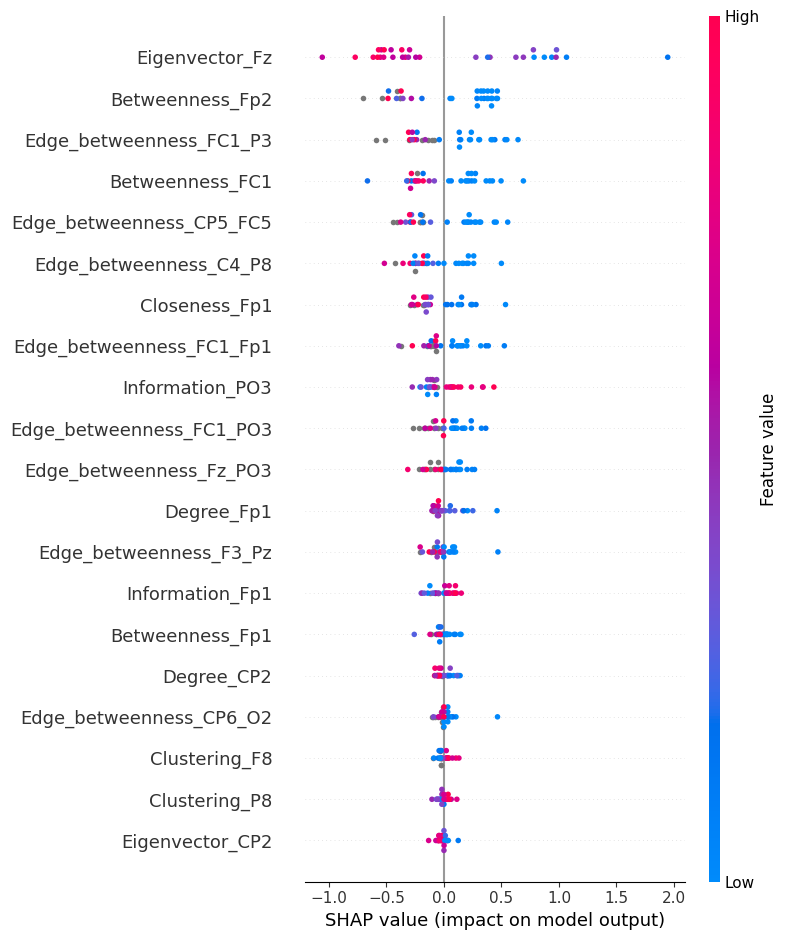

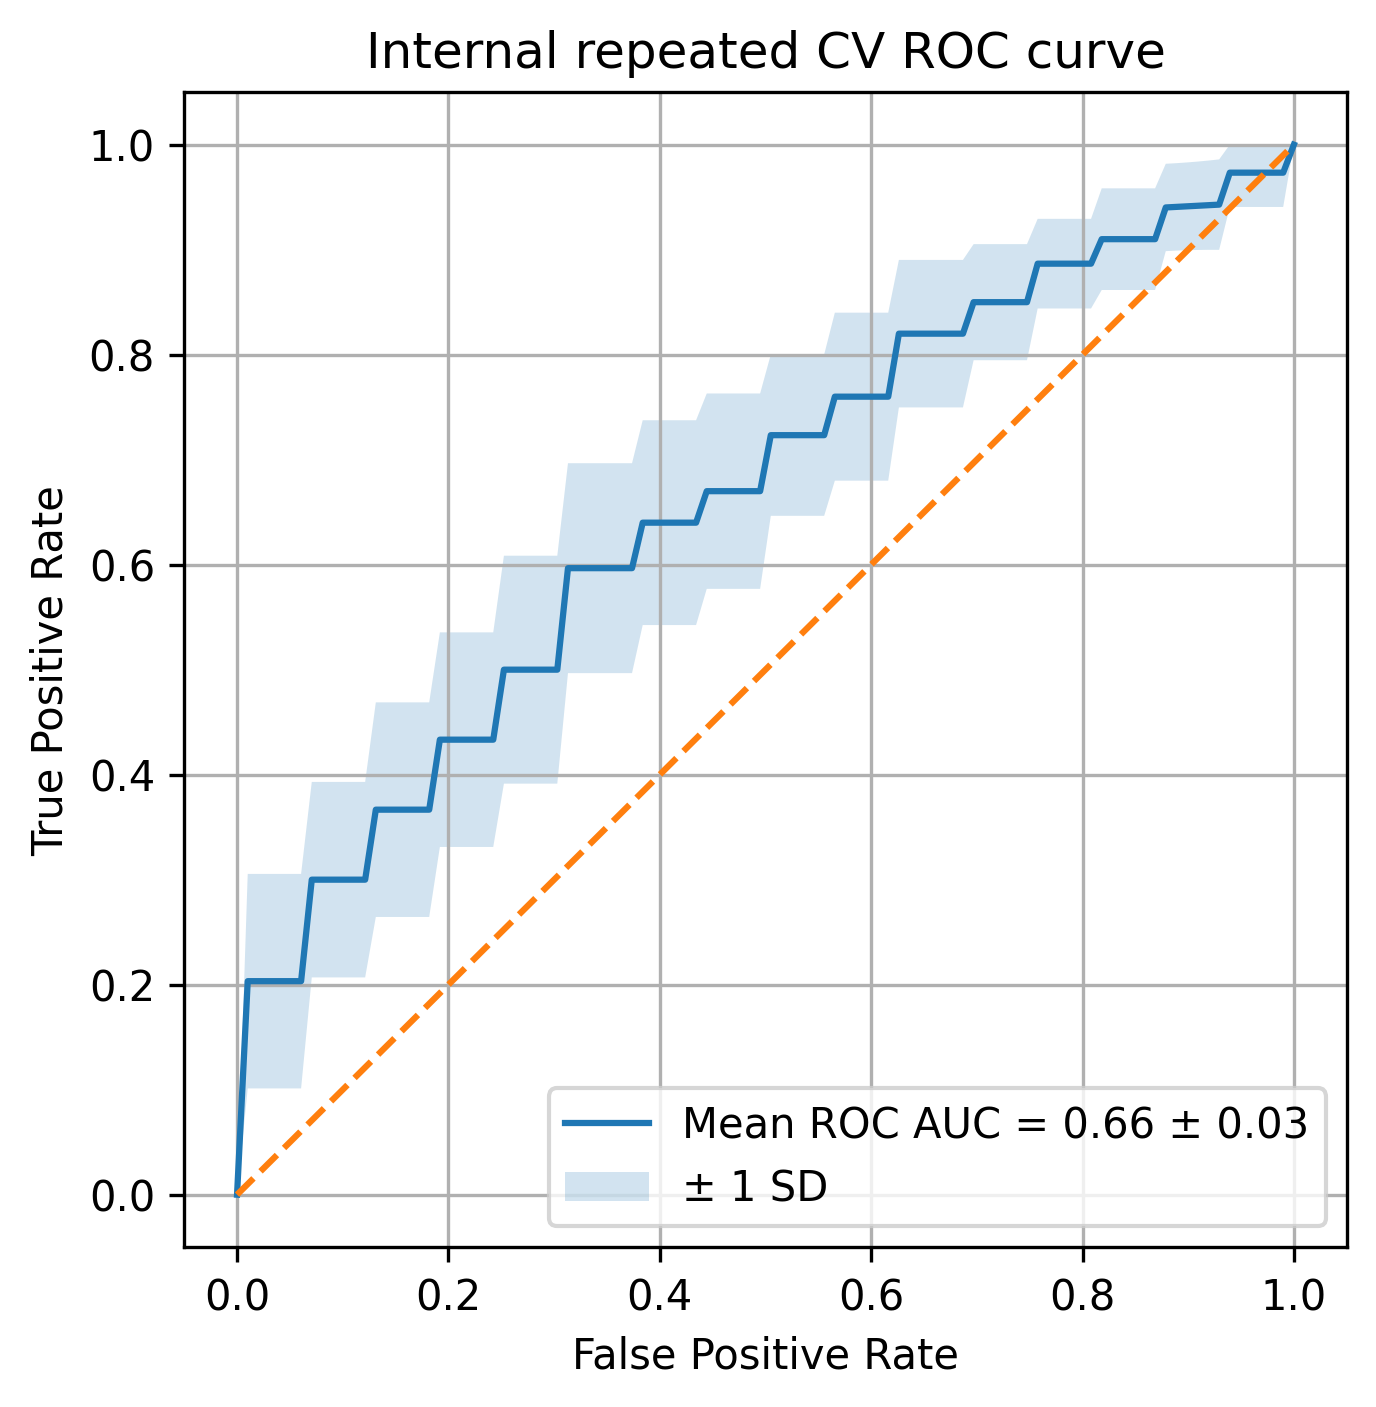

In [9]:
results_wPLI_XGB = cml.repeated_cv_classification_default(
    df=connectome_feat_2,
    target_col="Label",
    classifier="xgb",
    n_splits=10,
    n_repeats=20,
    plot_shap=True,
    plot_roc=True,
    print_table=True
)

## Spearman

In [10]:
connectome_feat=pd.read_csv('/Users/donato/Library/CloudStorage/OneDrive-IstitutoNazionalediFisicaNucleare/Phd/EEG/connectome_all_frequencies.csv',sep=',',index_col=0)
connectome_feat.set_index('Subject',inplace=True)
connectome_feat

,Label,AF3_degree,AF4_degree,C3_degree,C4_degree,CP1_degree,CP2_degree,CP5_degree,CP6_degree,Cz_degree,...,PO3_PO4,PO3_Pz,PO3_T7,PO3_T8,PO4_Pz,PO4_T7,PO4_T8,Pz_T7,Pz_T8,T7_T8
Subject,,,,,,,,,,,,,,,,,,,,,
hc1,0,4.021866,8.736851,5.170235,8.803920,9.351143,10.003615,7.721436,7.349153,8.678013,...,0.0,0.000000,0.000000,0.019355,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
hc10,0,7.880526,7.793664,4.707475,5.431768,5.249059,4.314331,6.575215,NaN,5.236344,...,0.0,NaN,0.013228,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
hc18,0,8.875530,6.567709,7.432371,7.817816,8.404905,8.763860,6.682381,7.523922,8.405368,...,0.0,0.000000,0.000000,NaN,0.0,0.041379,NaN,NaN,NaN,NaN
hc2,0,7.435049,8.664709,NaN,4.664790,6.677880,6.338403,6.791858,6.054490,5.604605,...,0.0,0.000000,0.017241,0.000000,0.0,0.000000,0.096059,0.000000,0.000000,0.059113
hc20,0,NaN,5.846876,5.098936,4.315373,4.064469,NaN,4.684986,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc21,0,12.452231,13.199467,6.133920,5.704361,8.854673,8.876678,8.039343,7.187330,NaN,...,0.0,0.000000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
hc24,0,11.468845,5.714078,6.781060,4.064511,5.340082,4.944362,5.260223,7.141427,7.870605,...,NaN,NaN,NaN,NaN,0.0,0.000000,NaN,0.000000,NaN,NaN
hc25,0,NaN,NaN,6.779396,6.443348,6.357148,6.368016,6.332936,6.154955,6.759495,...,0.0,0.000000,0.025641,0.017094,0.0,0.000000,0.042735,0.000000,0.000000,0.099715
hc29,0,12.223968,9.607401,7.915206,6.423870,6.405034,6.696484,6.141012,8.111250,8.551888,...,0.0,0.000000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN


#### Preprocessing

In [11]:
# Filtra le colonne con meno del 40% di NaN
columns_to_keep_nan = get_columns_with_less_than_40_percent_nans(connectome_feat)

connectome_feat_1=connectome_feat[columns_to_keep_nan]

print(f"Colonne con meno del 40% di NaN: {len(columns_to_keep_nan)}")

connectome_feat_1

Colonne con meno del 40% di NaN: 640


,Label,AF3_degree,AF4_degree,C3_degree,C4_degree,CP1_degree,CP2_degree,CP5_degree,CP6_degree,Cz_degree,...,P8_PO3,P8_PO4,P8_Pz,P8_T7,PO3_PO4,PO3_Pz,PO3_T7,PO4_Pz,PO4_T7,Pz_T7
Subject,,,,,,,,,,,,,,,,,,,,,
hc1,0,4.021866,8.736851,5.170235,8.803920,9.351143,10.003615,7.721436,7.349153,8.678013,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
hc10,0,7.880526,7.793664,4.707475,5.431768,5.249059,4.314331,6.575215,NaN,5.236344,...,0.000000,0.0,NaN,0.000000,0.0,NaN,0.013228,NaN,0.000000,NaN
hc18,0,8.875530,6.567709,7.432371,7.817816,8.404905,8.763860,6.682381,7.523922,8.405368,...,0.000000,0.0,0.000000,0.055172,0.0,0.000000,0.000000,0.0,0.041379,NaN
hc2,0,7.435049,8.664709,NaN,4.664790,6.677880,6.338403,6.791858,6.054490,5.604605,...,0.004926,0.0,0.004926,0.000000,0.0,0.000000,0.017241,0.0,0.000000,0.000000
hc20,0,NaN,5.846876,5.098936,4.315373,4.064469,NaN,4.684986,NaN,NaN,...,NaN,NaN,0.073593,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc21,0,12.452231,13.199467,6.133920,5.704361,8.854673,8.876678,8.039343,7.187330,NaN,...,0.000000,0.0,0.000000,NaN,0.0,0.000000,NaN,0.0,NaN,NaN
hc24,0,11.468845,5.714078,6.781060,4.064511,5.340082,4.944362,5.260223,7.141427,7.870605,...,NaN,0.0,0.095238,0.013228,NaN,NaN,NaN,0.0,0.000000,0.000000
hc25,0,NaN,NaN,6.779396,6.443348,6.357148,6.368016,6.332936,6.154955,6.759495,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.025641,0.0,0.000000,0.000000
hc29,0,12.223968,9.607401,7.915206,6.423870,6.405034,6.696484,6.141012,8.111250,8.551888,...,0.000000,0.0,0.000000,NaN,0.0,0.000000,NaN,0.0,NaN,NaN


In [12]:
# Filtra le colonne altamente correlate eliminando quella con più NaN
columns_to_keep = remove_highly_correlated_with_nan(connectome_feat_1)
print("Variabili sopravissute:", columns_to_keep)
connectome_feat_2=connectome_feat_1.loc[:][columns_to_keep]

Variabili sopravissute: Index(['Label', 'AF4_degree', 'C3_degree', 'C4_degree', 'CP2_degree',
       'CP6_degree', 'Cz_degree', 'F3_degree', 'F4_degree', 'F7_degree',
       ...
       'P7_P8', 'P7_PO3', 'P7_PO4', 'P7_Pz', 'P7_T7', 'P8_PO4', 'P8_Pz',
       'P8_T7', 'PO3_PO4', 'PO4_Pz'],
      dtype='object', length=426)


[18:17:47] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:47] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:47] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:47] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:48] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:17:52] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:52] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:52] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:52] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:52] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:17:56] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:56] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:56] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:56] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:17:56] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:18:00] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:18:00] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:18:01] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:18:01] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:18:01] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:18:05] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:18:05] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:18:05] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:18:05] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:18:05] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:18:09] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:18:09] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:18:09] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:18:09] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:18:10] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 


Internal repeated cross-validation
Classifier: xgb
CV type: stratified
Sampling: none
Repeats: 20
Folds: 10

           Metric   Mean ± SD       95% CI
          ROC AUC 0.83 (0.03) [0.77, 0.90]
         Accuracy 0.75 (0.05) [0.66, 0.85]
      Sensitivity 0.70 (0.09) [0.53, 0.86]
      Specificity 0.80 (0.06) [0.68, 0.92]
        Precision 0.77 (0.06) [0.66, 0.88]
Average Precision 0.86 (0.03) [0.81, 0.91]


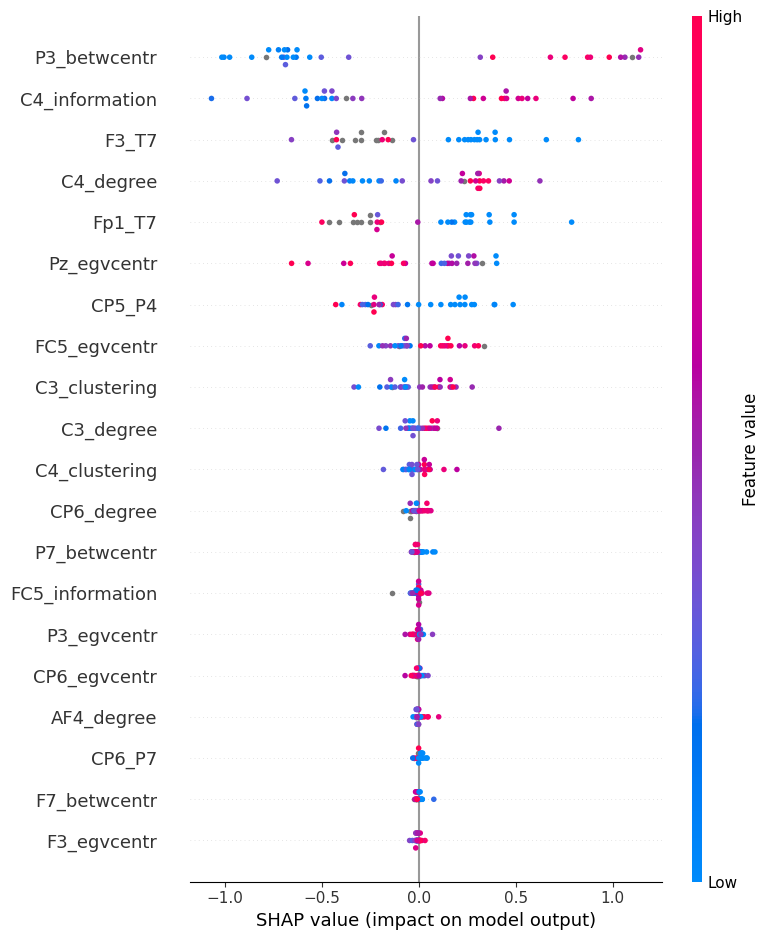

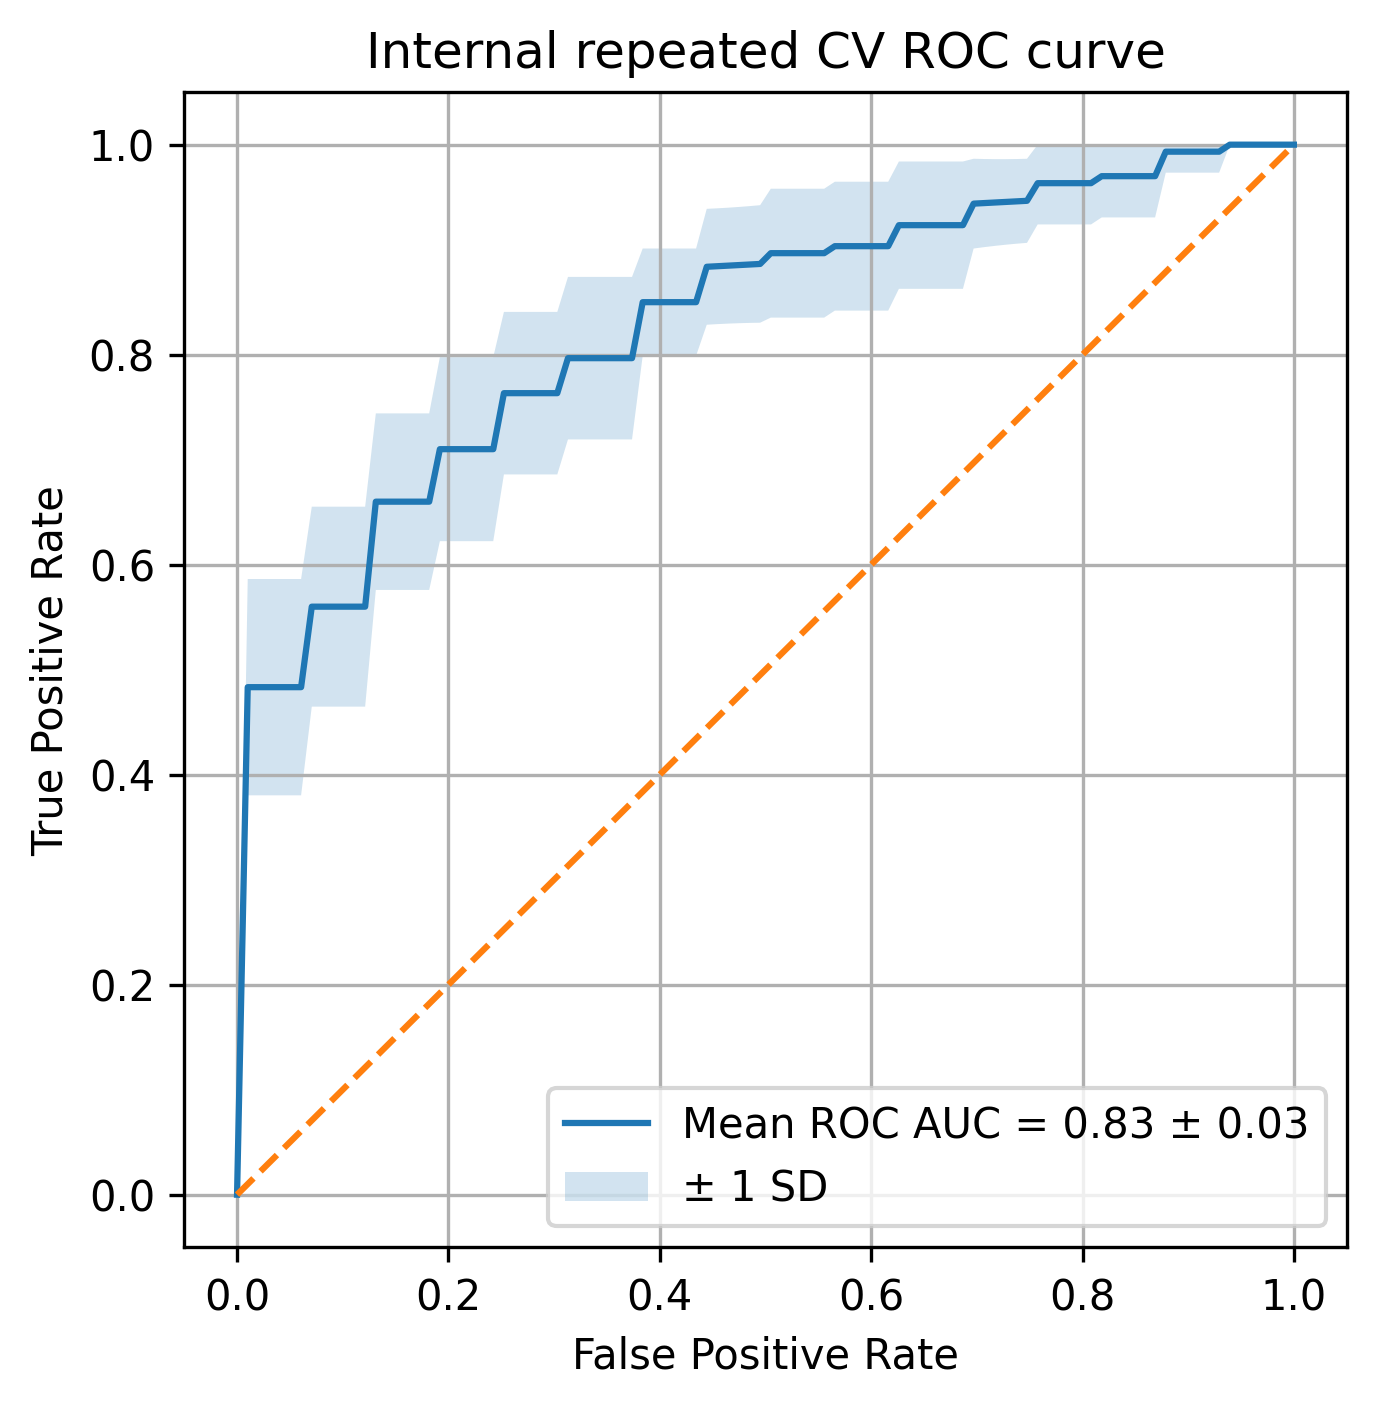

In [13]:
results_spear_XGB = cml.repeated_cv_classification_default(
    df=connectome_feat_2,
    target_col="Label",
    classifier="xgb",
    n_splits=10,
    n_repeats=20,
    plot_shap=True,
    plot_roc=True,
    print_table=True
)

## PLV

In [6]:
connectome_feat=pd.read_csv('/Users/donato/Library/CloudStorage/OneDrive-IstitutoNazionalediFisicaNucleare/Phd/EEG/connectome_0.5_100Hz_mne_PLV_individual_channels_density_070.csv',sep=',',index_col=0)
#connectome_feat.set_index('Subject',inplace=True)
connectome_feat

,Label,Degree_AF3,Degree_AF4,Degree_C3,Degree_C4,Degree_CP1,Degree_CP2,Degree_CP5,Degree_CP6,Degree_Cz,...,Edge_betweenness_AF3_F8,Edge_betweenness_F4_T8,Edge_betweenness_AF4_T8,Edge_betweenness_F3_T8,Edge_betweenness_F4_F7,Edge_betweenness_AF4_FC5,Edge_betweenness_F4_FC5,Edge_betweenness_P7_T8,Edge_betweenness_O2_T8,Edge_betweenness_Pz_T8
Subject,,,,,,,,,,,,,,,,,,,,,
hc1,0,7.891353,13.913024,8.795900,14.848448,14.367066,15.372557,11.787329,10.237287,13.937476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc10,0,13.039373,10.620471,9.514663,10.255337,8.058034,5.221292,10.255788,NaN,10.266258,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc18,0,17.356563,3.099036,14.889601,14.535346,17.238582,18.870215,13.086288,13.016982,16.724572,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc2,0,12.668792,12.541440,NaN,6.825424,13.814207,12.660563,11.749892,12.229005,10.366700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc20,0,NaN,9.283612,10.087037,7.226992,7.325023,NaN,8.895099,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc21,0,14.395883,14.223481,14.552739,12.075057,11.113636,15.002545,15.685116,12.361794,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc24,0,15.027069,9.346600,13.304762,9.073411,11.690116,10.715368,9.409455,10.906825,14.009590,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc25,0,NaN,NaN,16.037654,15.552319,17.037264,17.686289,13.405490,15.451593,17.833573,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc29,0,14.581981,8.047823,10.006750,11.020917,12.756910,12.423341,10.056916,10.182605,13.419446,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Filtra le colonne con meno del 40% di NaN
columns_to_keep_nan = get_columns_with_less_than_40_percent_nans(connectome_feat)

connectome_feat_2=connectome_feat[columns_to_keep_nan]

print(f"Colonne con meno del 40% di NaN: {len(columns_to_keep_nan)}")

connectome_feat_2

Colonne con meno del 40% di NaN: 441


,Label,Degree_AF3,Degree_AF4,Degree_C3,Degree_C4,Degree_CP1,Degree_CP2,Degree_CP5,Degree_CP6,Degree_Cz,...,Edge_betweenness_AF3_F3,Edge_betweenness_F3_F7,Edge_betweenness_F3_Fp1,Edge_betweenness_F3_P4,Edge_betweenness_F3_P8,Edge_betweenness_C3_F3,Edge_betweenness_C3_P8,Edge_betweenness_AF3_P8,Edge_betweenness_CP5_FC2,Edge_betweenness_CP1_F4
Subject,,,,,,,,,,,,,,,,,,,,,
hc1,0,7.891353,13.913024,8.795900,14.848448,14.367066,15.372557,11.787329,10.237287,13.937476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc10,0,13.039373,10.620471,9.514663,10.255337,8.058034,5.221292,10.255788,NaN,10.266258,...,0.002646,0.002646,0.015873,0.002646,0.005291,0.002646,0.007937,0.002646,0.002646,0.002646
hc18,0,17.356563,3.099036,14.889601,14.535346,17.238582,18.870215,13.086288,13.016982,16.724572,...,0.004598,0.004598,0.002299,0.002299,0.002299,0.006897,NaN,0.004598,NaN,0.004598
hc2,0,12.668792,12.541440,NaN,6.825424,13.814207,12.660563,11.749892,12.229005,10.366700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002463,0.002463,0.002463
hc20,0,NaN,9.283612,10.087037,7.226992,7.325023,NaN,8.895099,NaN,NaN,...,NaN,NaN,NaN,0.004329,NaN,0.021645,0.004329,NaN,0.004329,0.004329
hc21,0,14.395883,14.223481,14.552739,12.075057,11.113636,15.002545,15.685116,12.361794,NaN,...,0.002849,0.005698,0.002849,0.002849,0.002849,0.008547,0.017094,0.008547,0.005698,0.002849
hc24,0,15.027069,9.346600,13.304762,9.073411,11.690116,10.715368,9.409455,10.906825,14.009590,...,0.002646,NaN,0.002646,0.002646,0.002646,0.005291,0.002646,0.005291,NaN,NaN
hc25,0,NaN,NaN,16.037654,15.552319,17.037264,17.686289,13.405490,15.451593,17.833573,...,NaN,NaN,0.002849,NaN,NaN,0.017094,0.002849,NaN,NaN,NaN
hc29,0,14.581981,8.047823,10.006750,11.020917,12.756910,12.423341,10.056916,10.182605,13.419446,...,0.004926,NaN,0.002463,0.002463,0.002463,0.004926,0.004926,0.002463,0.002463,NaN


[18:51:13] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:13] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:13] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:13] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:13] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:51:17] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:17] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:17] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:17] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:17] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:51:21] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:21] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:21] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:22] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:22] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:51:25] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:25] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:26] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:26] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:26] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:51:29] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:29] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:30] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:30] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:30] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[18:51:33] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:34] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:34] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:34] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[18:51:34] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 


Internal repeated cross-validation
Classifier: xgb
CV type: stratified
Sampling: none
Repeats: 20
Folds: 10

           Metric   Mean ± SD       95% CI
          ROC AUC 0.69 (0.04) [0.61, 0.76]
         Accuracy 0.63 (0.06) [0.52, 0.74]
      Sensitivity 0.61 (0.06) [0.49, 0.73]
      Specificity 0.64 (0.08) [0.49, 0.80]
        Precision 0.62 (0.06) [0.49, 0.74]
Average Precision 0.71 (0.05) [0.62, 0.80]


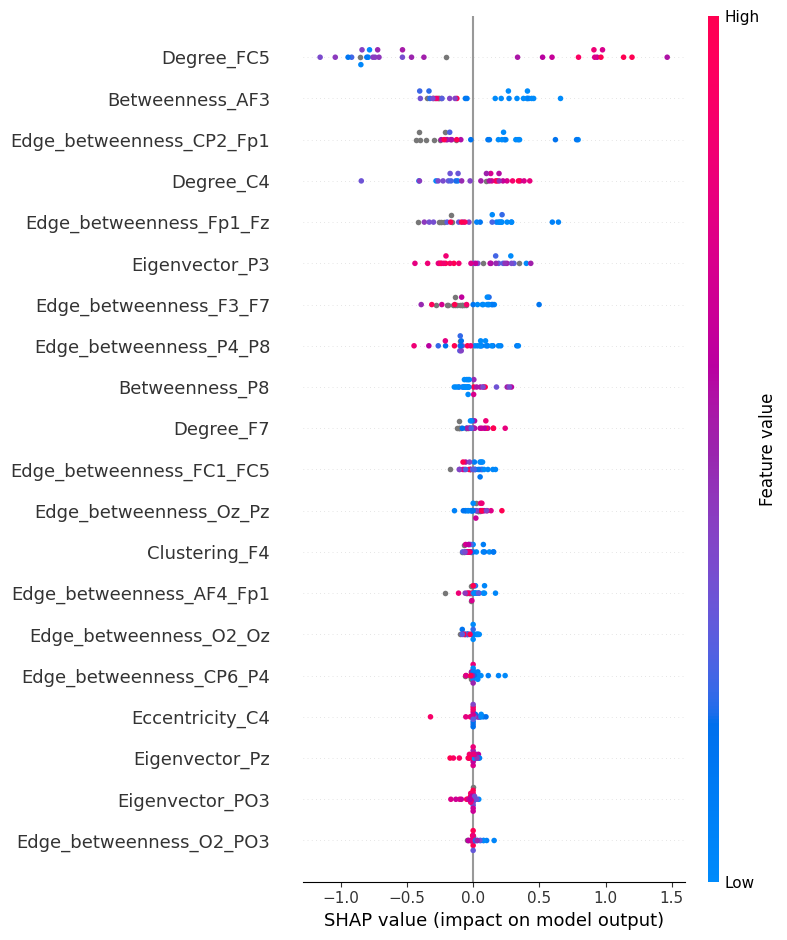

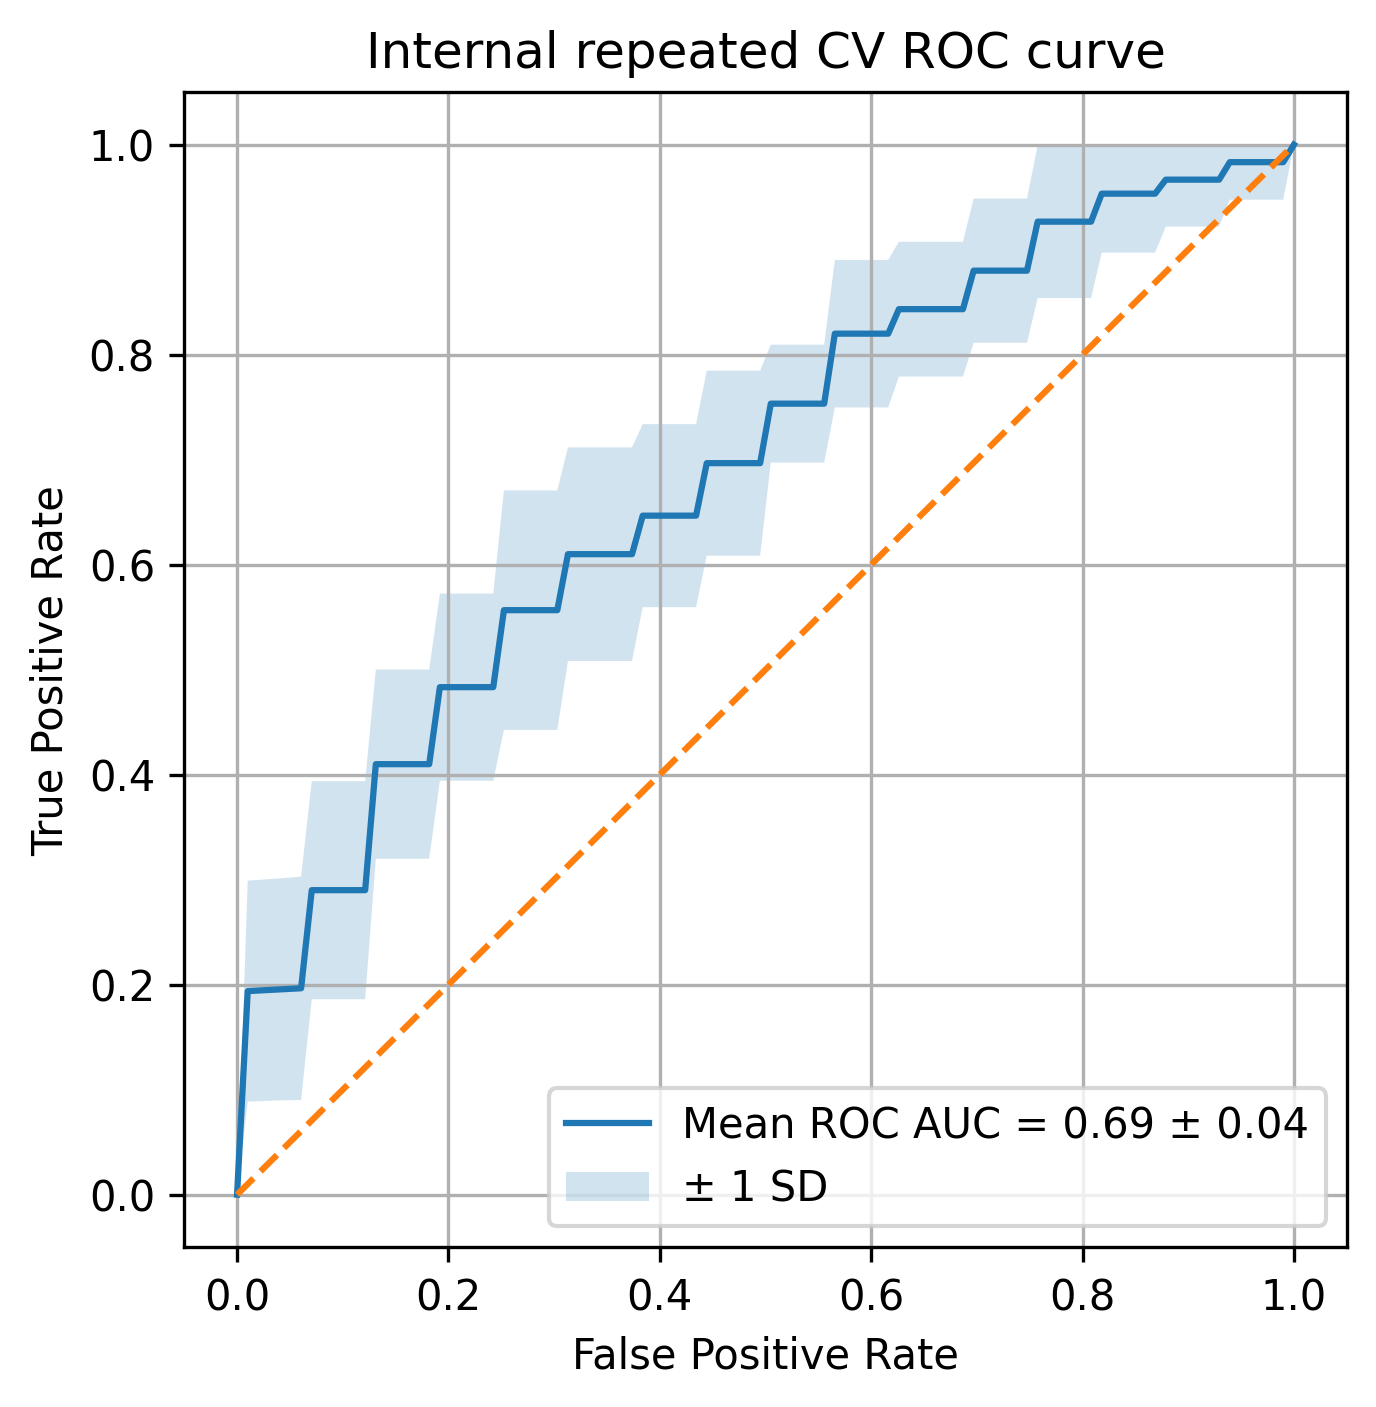

In [12]:
results_PLV_XGB = cml.repeated_cv_classification_default(
    df=connectome_feat_2,
    target_col="Label",
    classifier="xgb",
    n_splits=10,
    n_repeats=20,
    plot_shap=True,
    plot_roc=True,
    print_table=True
)

# Step 2:Valutazione del modello migliore

In [4]:
connectome_feat=pd.read_csv('/Users/donato/Library/CloudStorage/OneDrive-IstitutoNazionalediFisicaNucleare/Phd/EEG/connectome_all_frequencies.csv',sep=',',index_col=0)
connectome_feat.set_index('Subject',inplace=True)
connectome_feat

,Label,AF3_degree,AF4_degree,C3_degree,C4_degree,CP1_degree,CP2_degree,CP5_degree,CP6_degree,Cz_degree,...,PO3_PO4,PO3_Pz,PO3_T7,PO3_T8,PO4_Pz,PO4_T7,PO4_T8,Pz_T7,Pz_T8,T7_T8
Subject,,,,,,,,,,,,,,,,,,,,,
hc1,0,4.021866,8.736851,5.170235,8.803920,9.351143,10.003615,7.721436,7.349153,8.678013,...,0.0,0.000000,0.000000,0.019355,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
hc10,0,7.880526,7.793664,4.707475,5.431768,5.249059,4.314331,6.575215,NaN,5.236344,...,0.0,NaN,0.013228,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
hc18,0,8.875530,6.567709,7.432371,7.817816,8.404905,8.763860,6.682381,7.523922,8.405368,...,0.0,0.000000,0.000000,NaN,0.0,0.041379,NaN,NaN,NaN,NaN
hc2,0,7.435049,8.664709,NaN,4.664790,6.677880,6.338403,6.791858,6.054490,5.604605,...,0.0,0.000000,0.017241,0.000000,0.0,0.000000,0.096059,0.000000,0.000000,0.059113
hc20,0,NaN,5.846876,5.098936,4.315373,4.064469,NaN,4.684986,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc21,0,12.452231,13.199467,6.133920,5.704361,8.854673,8.876678,8.039343,7.187330,NaN,...,0.0,0.000000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
hc24,0,11.468845,5.714078,6.781060,4.064511,5.340082,4.944362,5.260223,7.141427,7.870605,...,NaN,NaN,NaN,NaN,0.0,0.000000,NaN,0.000000,NaN,NaN
hc25,0,NaN,NaN,6.779396,6.443348,6.357148,6.368016,6.332936,6.154955,6.759495,...,0.0,0.000000,0.025641,0.017094,0.0,0.000000,0.042735,0.000000,0.000000,0.099715
hc29,0,12.223968,9.607401,7.915206,6.423870,6.405034,6.696484,6.141012,8.111250,8.551888,...,0.0,0.000000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN


In [11]:
# Filtra le colonne con meno del 40% di NaN
columns_to_keep_nan = get_columns_with_less_than_40_percent_nans(connectome_feat)

connectome_feat_1=connectome_feat[columns_to_keep_nan]

print(f"Colonne con meno del 40% di NaN: {len(columns_to_keep_nan)}")

connectome_feat_1

Colonne con meno del 40% di NaN: 640


,Label,AF3_degree,AF4_degree,C3_degree,C4_degree,CP1_degree,CP2_degree,CP5_degree,CP6_degree,Cz_degree,...,P8_PO3,P8_PO4,P8_Pz,P8_T7,PO3_PO4,PO3_Pz,PO3_T7,PO4_Pz,PO4_T7,Pz_T7
Subject,,,,,,,,,,,,,,,,,,,,,
hc1,0,4.021866,8.736851,5.170235,8.803920,9.351143,10.003615,7.721436,7.349153,8.678013,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
hc10,0,7.880526,7.793664,4.707475,5.431768,5.249059,4.314331,6.575215,NaN,5.236344,...,0.000000,0.0,NaN,0.000000,0.0,NaN,0.013228,NaN,0.000000,NaN
hc18,0,8.875530,6.567709,7.432371,7.817816,8.404905,8.763860,6.682381,7.523922,8.405368,...,0.000000,0.0,0.000000,0.055172,0.0,0.000000,0.000000,0.0,0.041379,NaN
hc2,0,7.435049,8.664709,NaN,4.664790,6.677880,6.338403,6.791858,6.054490,5.604605,...,0.004926,0.0,0.004926,0.000000,0.0,0.000000,0.017241,0.0,0.000000,0.000000
hc20,0,NaN,5.846876,5.098936,4.315373,4.064469,NaN,4.684986,NaN,NaN,...,NaN,NaN,0.073593,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc21,0,12.452231,13.199467,6.133920,5.704361,8.854673,8.876678,8.039343,7.187330,NaN,...,0.000000,0.0,0.000000,NaN,0.0,0.000000,NaN,0.0,NaN,NaN
hc24,0,11.468845,5.714078,6.781060,4.064511,5.340082,4.944362,5.260223,7.141427,7.870605,...,NaN,0.0,0.095238,0.013228,NaN,NaN,NaN,0.0,0.000000,0.000000
hc25,0,NaN,NaN,6.779396,6.443348,6.357148,6.368016,6.332936,6.154955,6.759495,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.025641,0.0,0.000000,0.000000
hc29,0,12.223968,9.607401,7.915206,6.423870,6.405034,6.696484,6.141012,8.111250,8.551888,...,0.000000,0.0,0.000000,NaN,0.0,0.000000,NaN,0.0,NaN,NaN


In [12]:
# Filtra le colonne altamente correlate eliminando quella con più NaN
columns_to_keep = remove_highly_correlated_with_nan(connectome_feat_1)
print("Variabili sopravissute:", columns_to_keep)
connectome_feat_2=connectome_feat_1.loc[:][columns_to_keep]

Variabili sopravissute: Index(['Label', 'AF4_degree', 'C3_degree', 'C4_degree', 'CP2_degree',
       'CP6_degree', 'Cz_degree', 'F3_degree', 'F4_degree', 'F7_degree',
       ...
       'P7_P8', 'P7_PO3', 'P7_PO4', 'P7_Pz', 'P7_T7', 'P8_PO4', 'P8_Pz',
       'P8_T7', 'PO3_PO4', 'PO4_Pz'],
      dtype='object', length=426)


## RF


Internal repeated cross-validation
Classifier: Randomforest
CV type: stratified
Sampling: none
Repeats: 20
Folds: 10

           Metric   Mean ± SD       95% CI
          ROC AUC 0.80 (0.02) [0.76, 0.85]
         Accuracy 0.78 (0.05) [0.67, 0.88]
      Sensitivity 0.73 (0.05) [0.64, 0.82]
      Specificity 0.82 (0.09) [0.64, 1.00]
        Precision 0.80 (0.08) [0.64, 0.96]
Average Precision 0.86 (0.02) [0.83, 0.89]


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


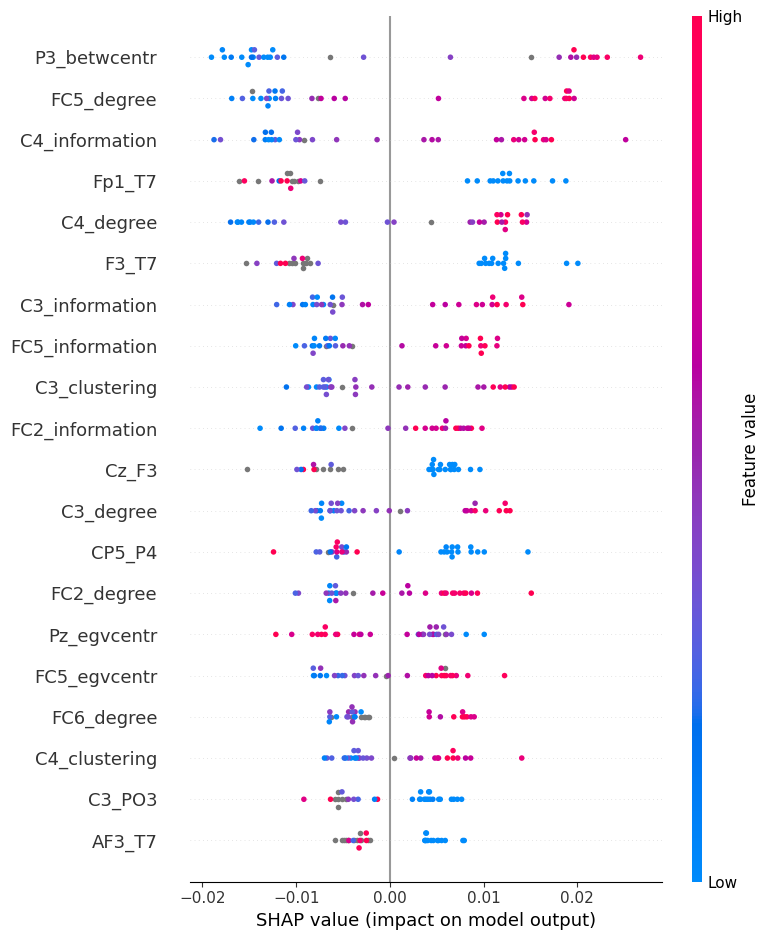

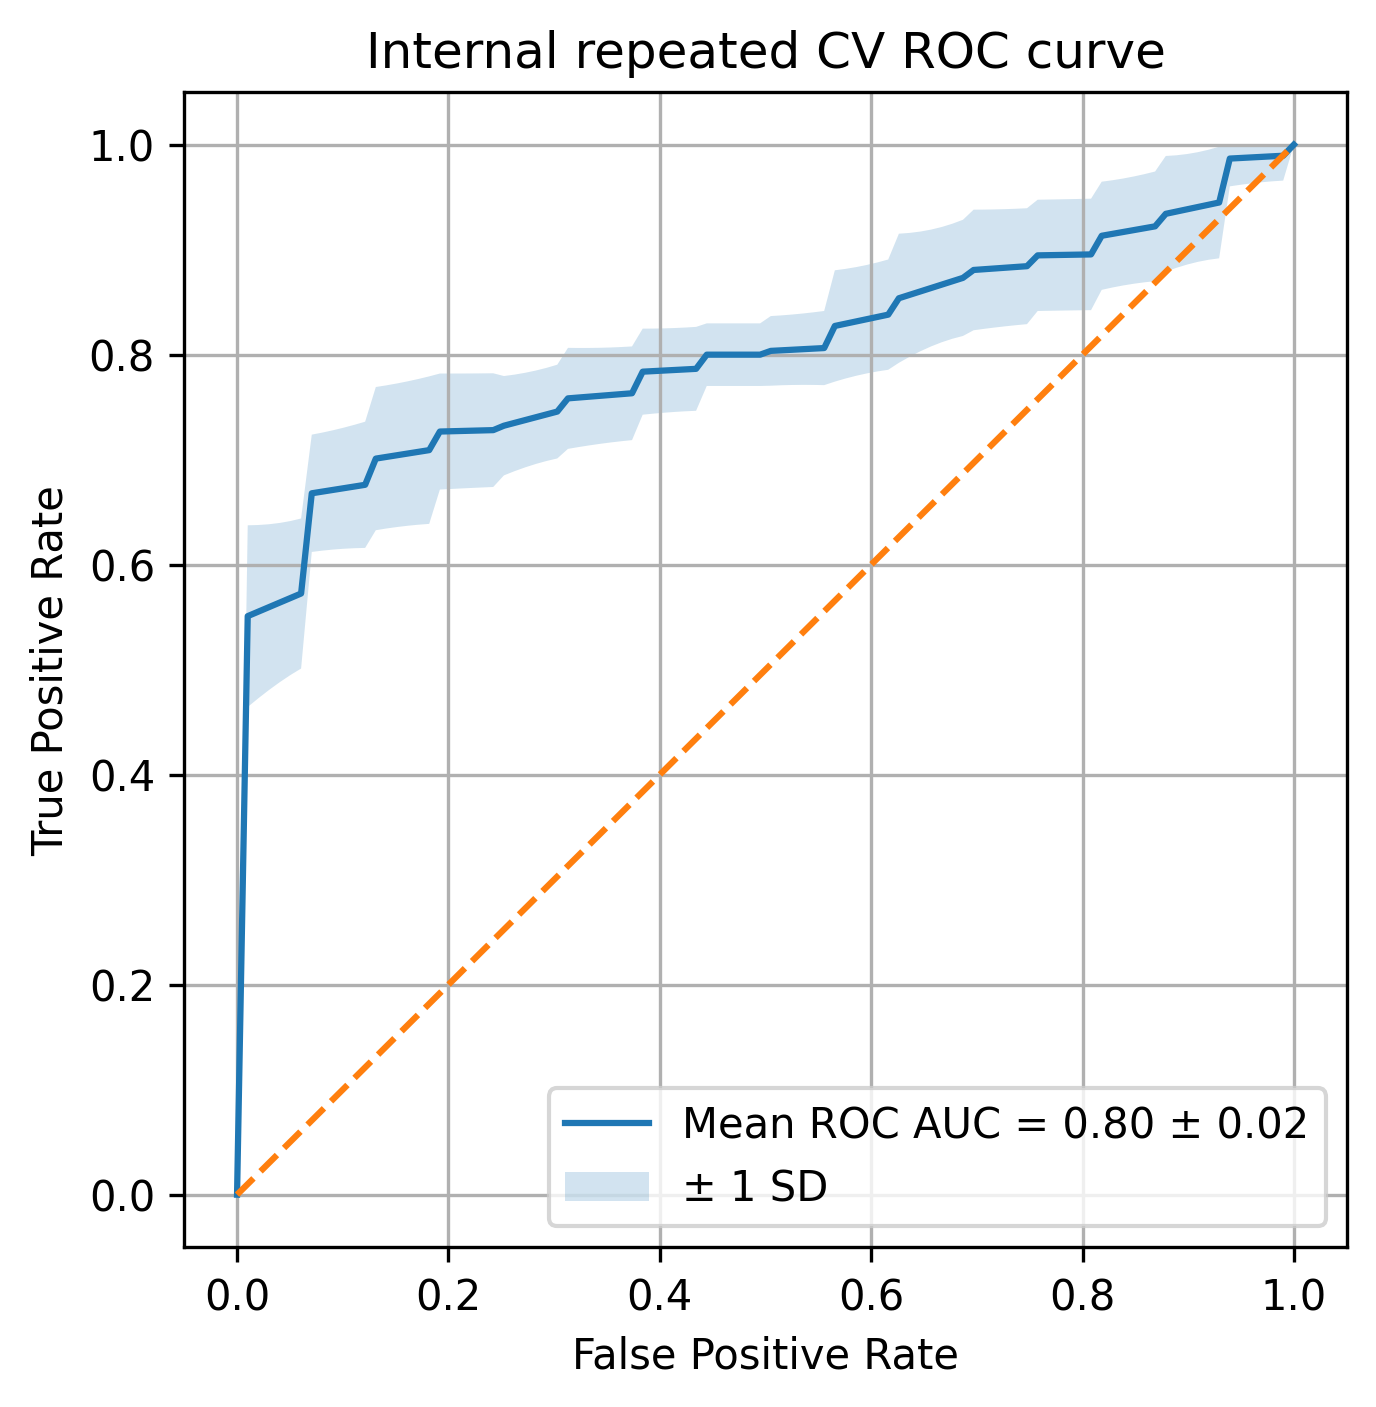

In [34]:
results_PLV_RF = cml.repeated_cv_classification_default(
    df=connectome_feat_1,
    target_col="Label",
    classifier="Randomforest",
    n_splits=10,
    n_repeats=20,
    plot_shap=True,
    plot_roc=True,
    print_table=True
)

## SVC

SHAP interno non calcolato nel repeat 0, fold 0: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 0, fold 1: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 0, fold 2: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 0, fold 3: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 0, fold 4: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 0, fold 5: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 0, fold 6: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 0, fold 7: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 0, fold 8: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 0, fold 

SHAP interno non calcolato nel repeat 8, fold 1: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 8, fold 2: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 8, fold 3: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 8, fold 4: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 8, fold 5: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 8, fold 6: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 8, fold 7: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 8, fold 8: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 8, fold 9: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 9, fold 

SHAP interno non calcolato nel repeat 16, fold 2: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 16, fold 3: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 16, fold 4: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 16, fold 5: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 16, fold 6: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 16, fold 7: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 16, fold 8: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 16, fold 9: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat 17, fold 0: Calcolo SHAP non implementato per il classificatore: svc
SHAP interno non calcolato nel repeat


Internal repeated cross-validation
Classifier: svc
CV type: stratified
Sampling: none
Repeats: 20
Folds: 10

           Metric   Mean ± SD       95% CI
          ROC AUC 0.59 (0.07) [0.45, 0.73]
         Accuracy 0.65 (0.02) [0.61, 0.68]
      Sensitivity 0.82 (0.03) [0.76, 0.88]
      Specificity 0.49 (0.03) [0.44, 0.54]
        Precision 0.60 (0.01) [0.57, 0.63]
Average Precision 0.56 (0.07) [0.42, 0.70]


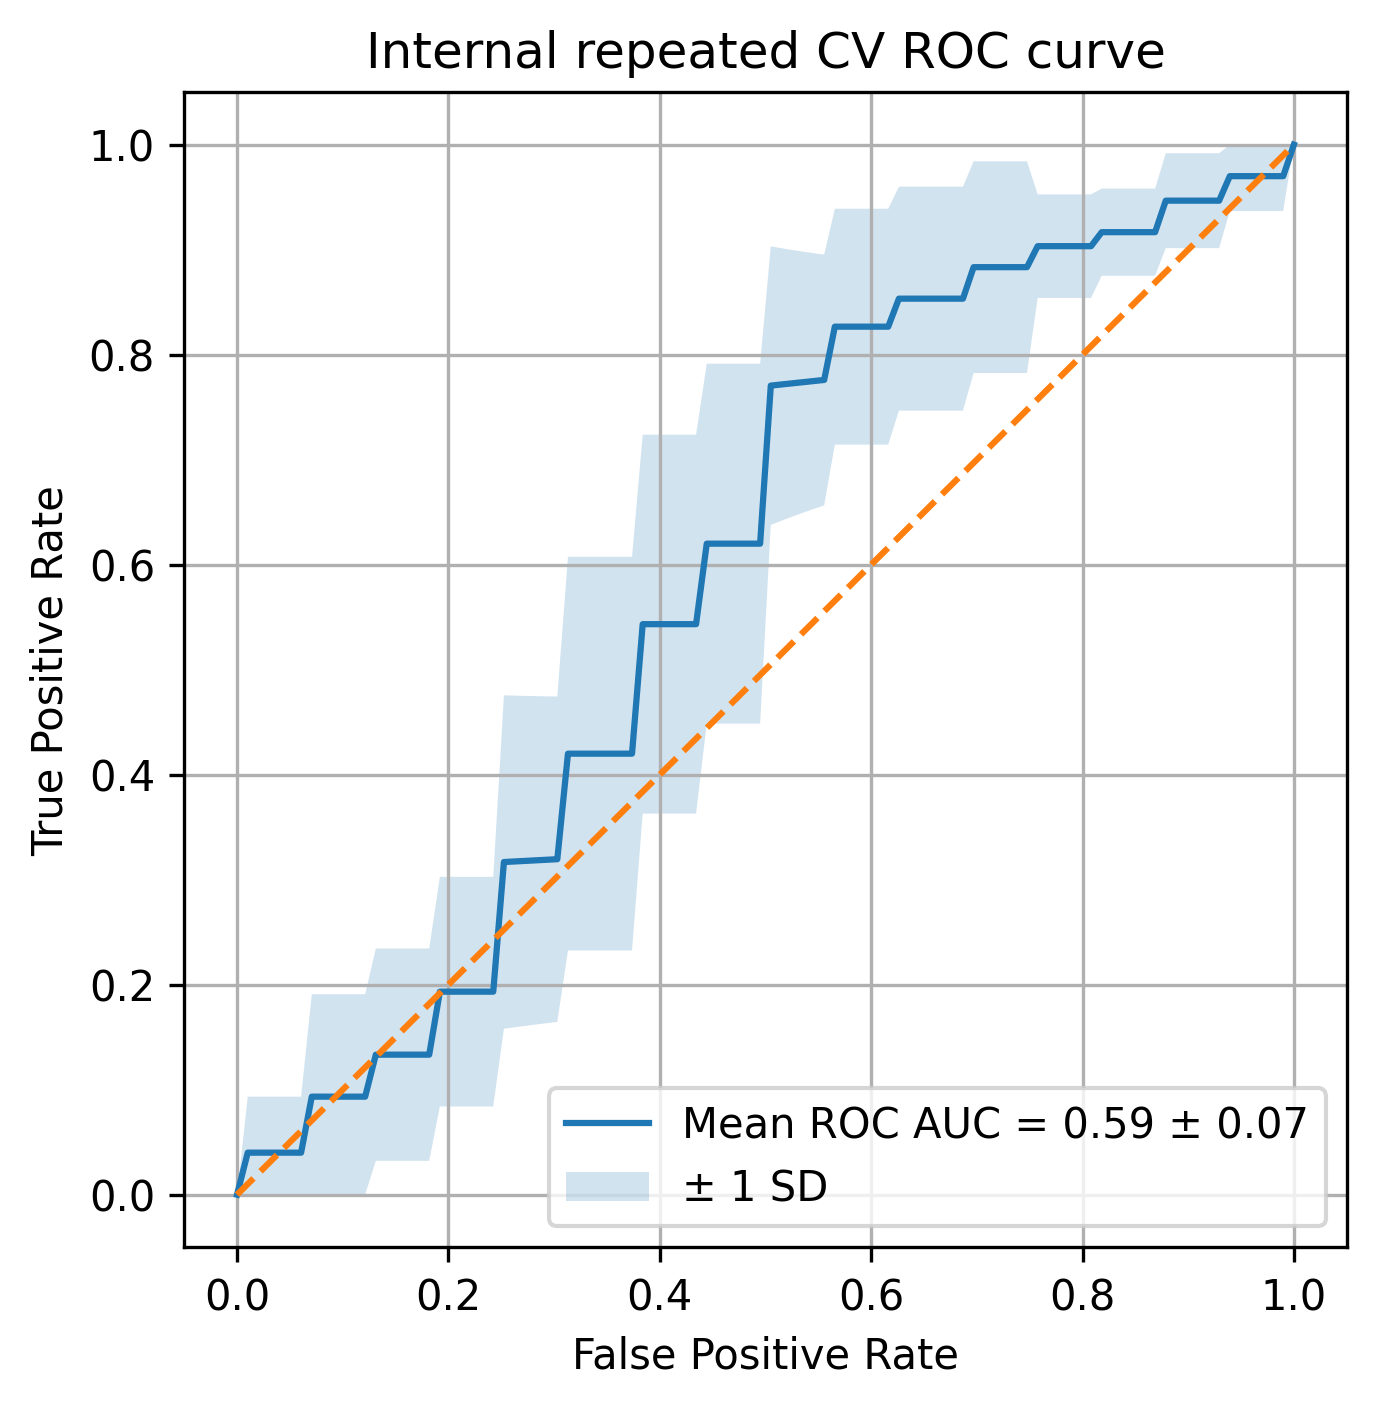

In [35]:
results_PLV_SVC = cml.repeated_cv_classification_default(
    df=connectome_feat_1,
    target_col="Label",
    classifier="svc",
    n_splits=10,
    n_repeats=20,
    plot_shap=True,
    plot_roc=True,
    print_table=True
)

### MLP

SHAP interno non calcolato nel repeat 0, fold 0: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 0, fold 1: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 0, fold 2: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 0, fold 3: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 0, fold 4: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 0, fold 5: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 0, fold 6: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 0, fold 7: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 0, fold 8: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 0, fold 

SHAP interno non calcolato nel repeat 7, fold 9: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 8, fold 0: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 8, fold 1: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 8, fold 2: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 8, fold 3: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 8, fold 4: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 8, fold 5: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 8, fold 6: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 8, fold 7: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 8, fold 

SHAP interno non calcolato nel repeat 15, fold 6: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 15, fold 7: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 15, fold 8: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 15, fold 9: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 16, fold 0: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 16, fold 1: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 16, fold 2: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 16, fold 3: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 16, fold 4: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat


Internal repeated cross-validation
Classifier: mlp
CV type: stratified
Sampling: none
Repeats: 20
Folds: 10

           Metric   Mean ± SD       95% CI
          ROC AUC 0.62 (0.10) [0.43, 0.81]
         Accuracy 0.56 (0.06) [0.46, 0.67]
      Sensitivity 0.52 (0.23) [0.08, 0.97]
      Specificity 0.60 (0.20) [0.22, 0.99]
        Precision 0.56 (0.08) [0.39, 0.72]
Average Precision 0.65 (0.08) [0.50, 0.79]


SHAP interno non calcolato nel repeat 19, fold 8: Calcolo SHAP non implementato per il classificatore: mlp
SHAP interno non calcolato nel repeat 19, fold 9: Calcolo SHAP non implementato per il classificatore: mlp


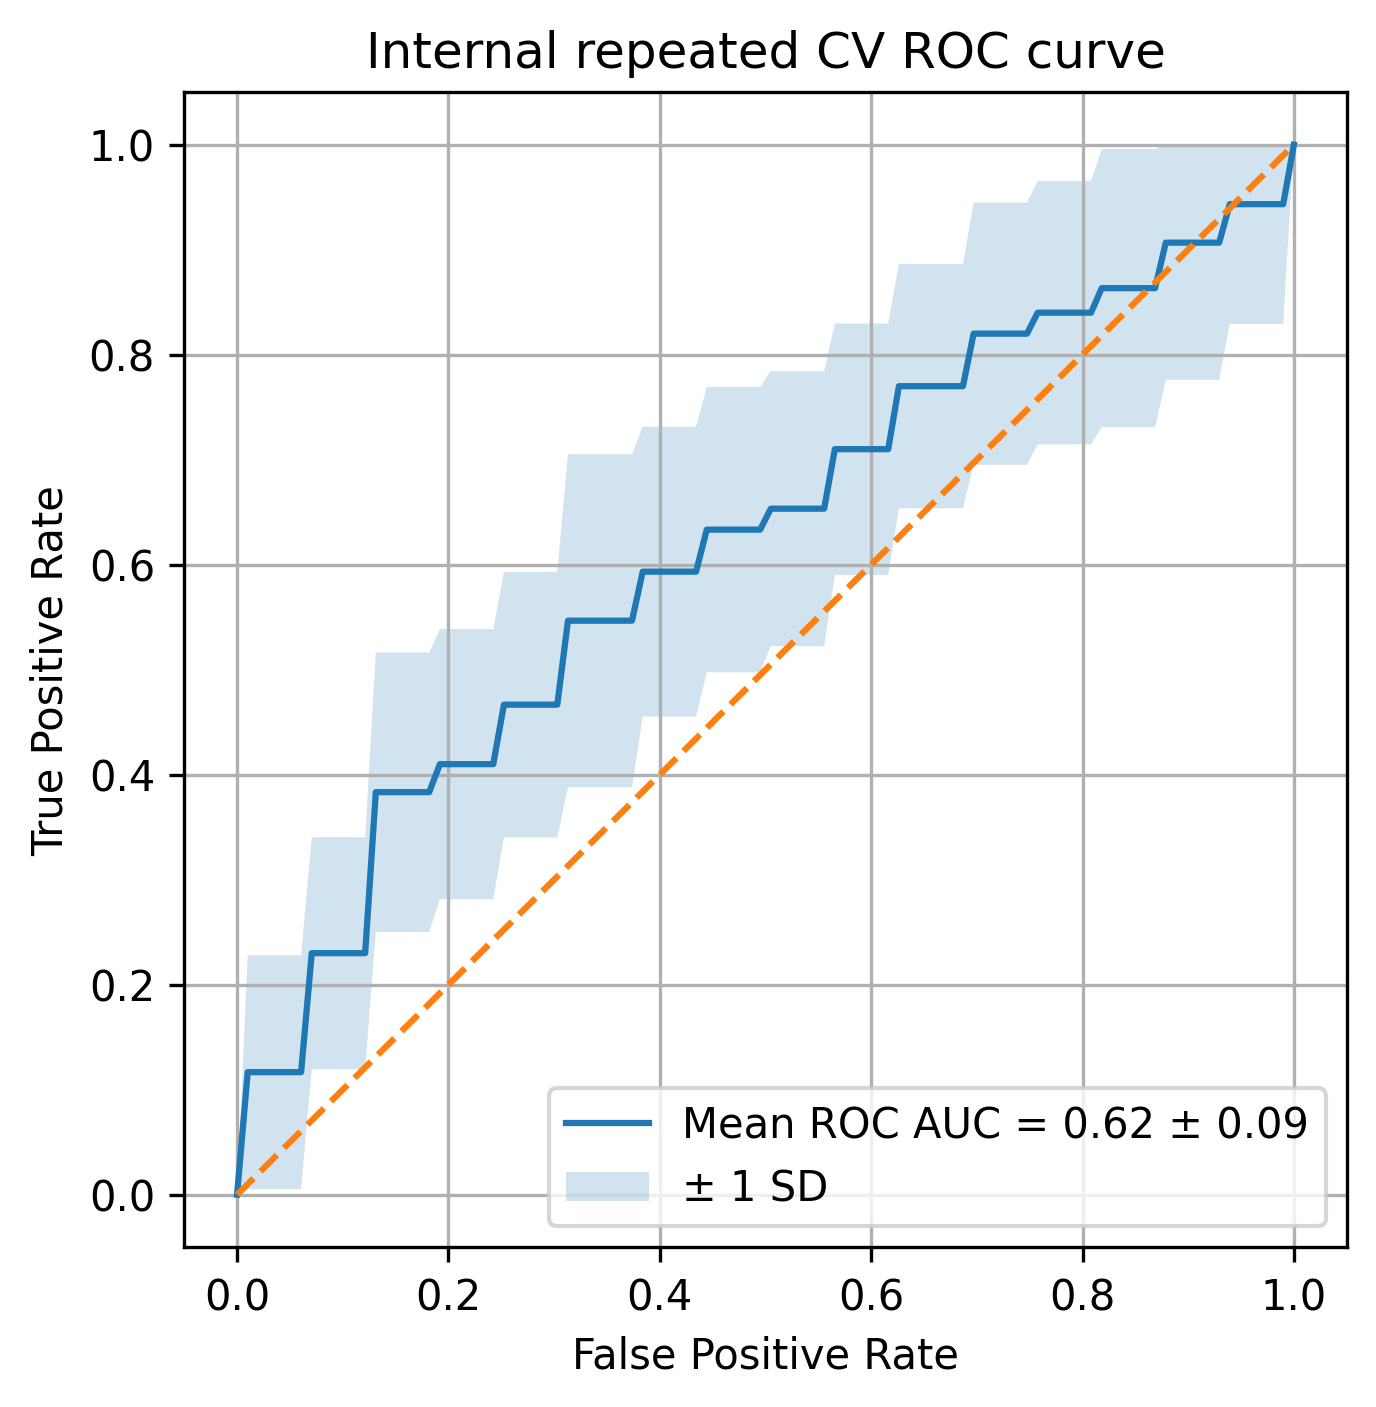

In [36]:
results_PLV_MLP = cml.repeated_cv_classification_default(
    df=connectome_feat_1,
    target_col="Label",
    classifier="mlp",
    n_splits=10,
    n_repeats=20,
    plot_shap=True,
    plot_roc=True,
    print_table=True
)

### XGB

[14:45:47] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:45:47] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:45:47] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:45:47] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:45:47] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[14:45:53] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:45:53] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:45:53] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:45:53] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:45:53] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[14:45:59] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:45:59] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:45:59] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:00] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:00] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[14:46:05] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:05] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:06] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:06] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:06] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[14:46:12] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:12] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:12] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:12] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:12] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[14:46:18] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:18] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:18] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:18] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[14:46:18] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 


Internal repeated cross-validation
Classifier: xgboost
CV type: stratified
Sampling: none
Repeats: 20
Folds: 10

           Metric   Mean ± SD       95% CI
          ROC AUC 0.85 (0.03) [0.79, 0.92]
         Accuracy 0.81 (0.04) [0.73, 0.89]
      Sensitivity 0.72 (0.05) [0.63, 0.82]
      Specificity 0.89 (0.05) [0.79, 1.00]
        Precision 0.87 (0.06) [0.74, 0.99]
Average Precision 0.89 (0.03) [0.84, 0.95]


[14:46:20] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


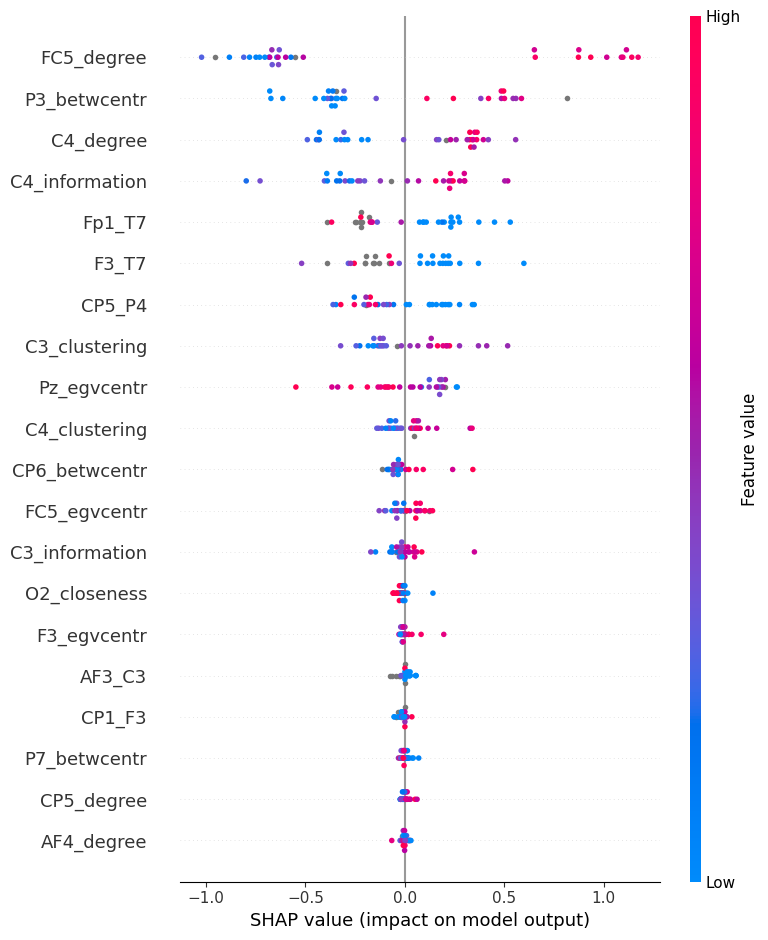

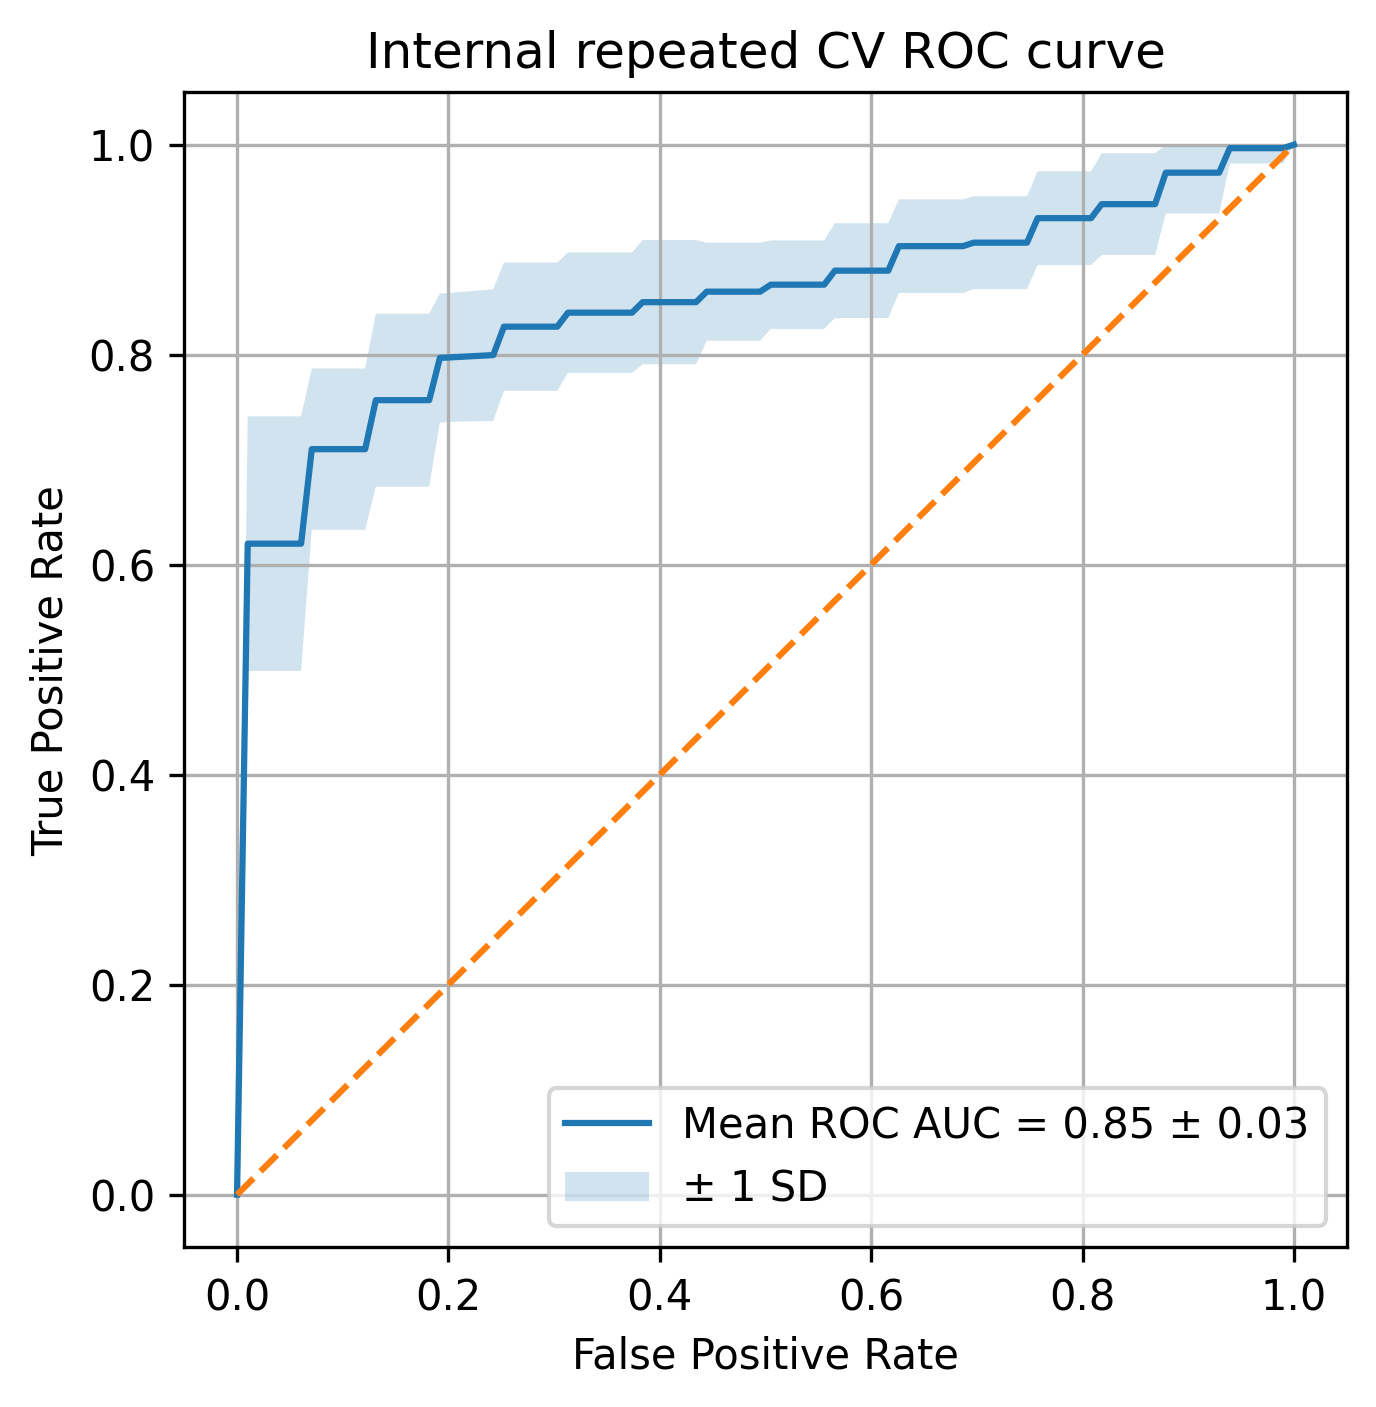

In [37]:
results_PLV_XGB = cml.repeated_cv_classification_default(
    df=connectome_feat_1,
    target_col="Label",
    classifier="xgboost",
    n_splits=10,
    n_repeats=20,
    plot_shap=True,
    plot_roc=True,
    print_table=True
)

## Confronto statistico tra i modelli

In [41]:
'''Modello XGB'''
df_XGB = results_PLV_XGB['internal_metrics_df'].drop(['repeat'],axis=1).copy()
df_XGB['Modello']='XGB'
df_XGB

'''Dieta RF'''
df_RF = results_PLV_RF['internal_metrics_df'].drop(['repeat'],axis=1).copy()
df_RF['Modello']='RF'
df_RF

'''Modello SVC'''
df_SVC = results_PLV_SVC['internal_metrics_df'].drop(['repeat'],axis=1).copy()
df_SVC['Modello']='SVC'
df_SVC

'''Dieta MLP'''
df_MLP = results_PLV_MLP['internal_metrics_df'].drop(['repeat'],axis=1).copy()
df_MLP['Modello']='MLP'
df_MLP


,accuracy,sensitivity,specificity,precision,roc_auc,average_precision,Modello
0,0.548387,0.800000,0.3125,0.521739,0.687500,0.650194,MLP
1,0.612903,0.466667,0.7500,0.636364,0.591667,0.672369,MLP
2,0.612903,0.866667,0.3750,0.565217,0.754167,0.765929,MLP
3,0.451613,0.133333,0.7500,0.333333,0.366667,0.489988,MLP
4,0.580645,0.266667,0.8750,0.666667,0.550000,0.603025,MLP
5,0.580645,0.866667,0.3125,0.541667,0.729167,0.759848,MLP
6,0.580645,0.733333,0.4375,0.550000,0.641667,0.640808,MLP
7,0.612903,0.400000,0.8125,0.666667,0.741667,0.655424,MLP
8,0.483871,0.533333,0.4375,0.470588,0.545833,0.577592,MLP
9,0.548387,0.400000,0.6875,0.545455,0.508333,0.576974,MLP


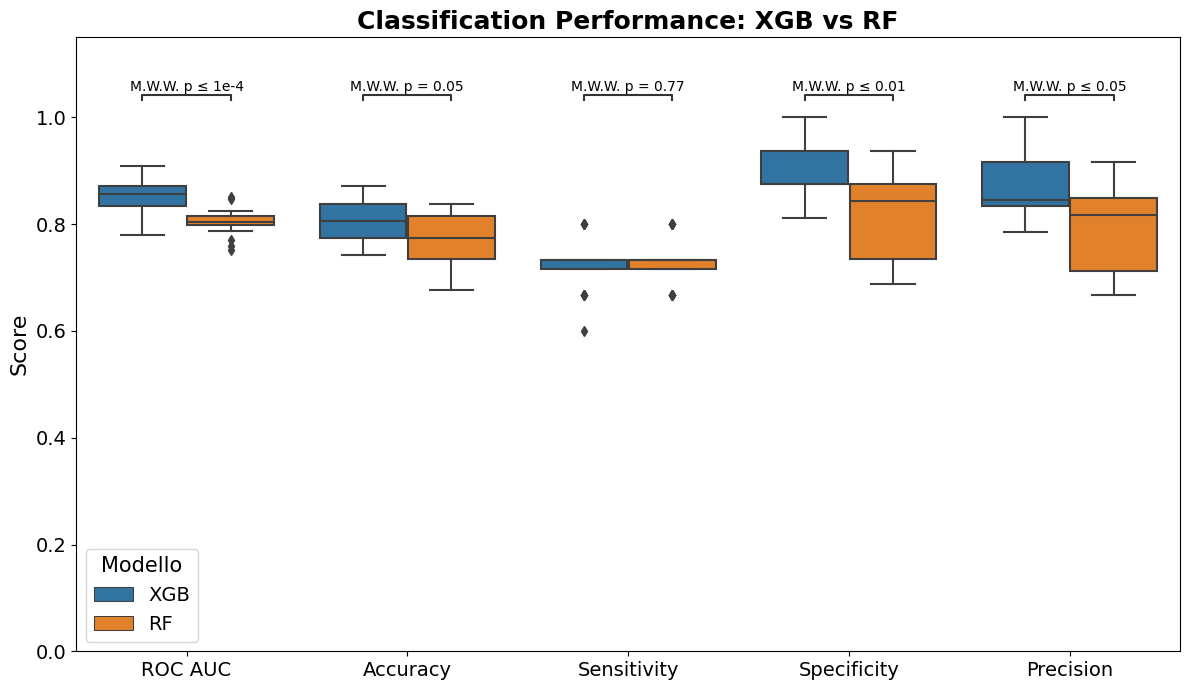

<Figure size 1920x1440 with 0 Axes>

In [59]:
''' XGB vs RF'''
# Unione
df = pd.concat([df_XGB, df_RF], ignore_index=True)
df.rename(columns={"roc_auc": "ROC AUC", "accuracy": "Accuracy", "sensitivity": "Sensitivity", "specificity":"Specificity", "precision":"Precision"}, inplace=True)

# Formato long per seaborn
df_long = df.melt(
    id_vars="Modello",
    value_vars=[
        "ROC AUC",
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision"
    ],
    var_name="Metric",
    value_name="Score"
)

#df_long["Modello"] = df_long["Modello"].map({
#    "A": "Polyphenol-Free",
#    "B": "Polyphenol-Rich"
#})


fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df_long,
    x="Metric",
    y="Score",
    hue="Modello",
    ax=ax
)



pairs = [
    (("ROC AUC", "XGB"), ("ROC AUC", "RF")),
    (("Accuracy", "XGB"), ("Accuracy", "RF")),
    (("Sensitivity", "XGB"), ("Sensitivity", "RF")),
    (("Specificity", "XGB"), ("Specificity", "RF")),
    (("Precision", "XGB"), ("Precision", "RF")),
]

annotator = Annotator(
    ax,
    pairs,
    data=df_long,
    x="Metric",
    y="Score",
    hue="Modello"
)

annotator.configure(
    test="Mann-Whitney",
    #comparisons_correction="bonferroni",
    #text_format="star",
    text_format="simple",
    loc="outside",
    verbose=0
)

annotator.apply_and_annotate()

ax.set_title(
    "Classification Performance: XGB vs RF",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Score", fontsize=16)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylim(0, 1.15)

ax.legend(
    title="Modello",
    title_fontsize=15,
    fontsize=14
)

plt.tight_layout()
plt.figure(dpi=300)
plt.show()

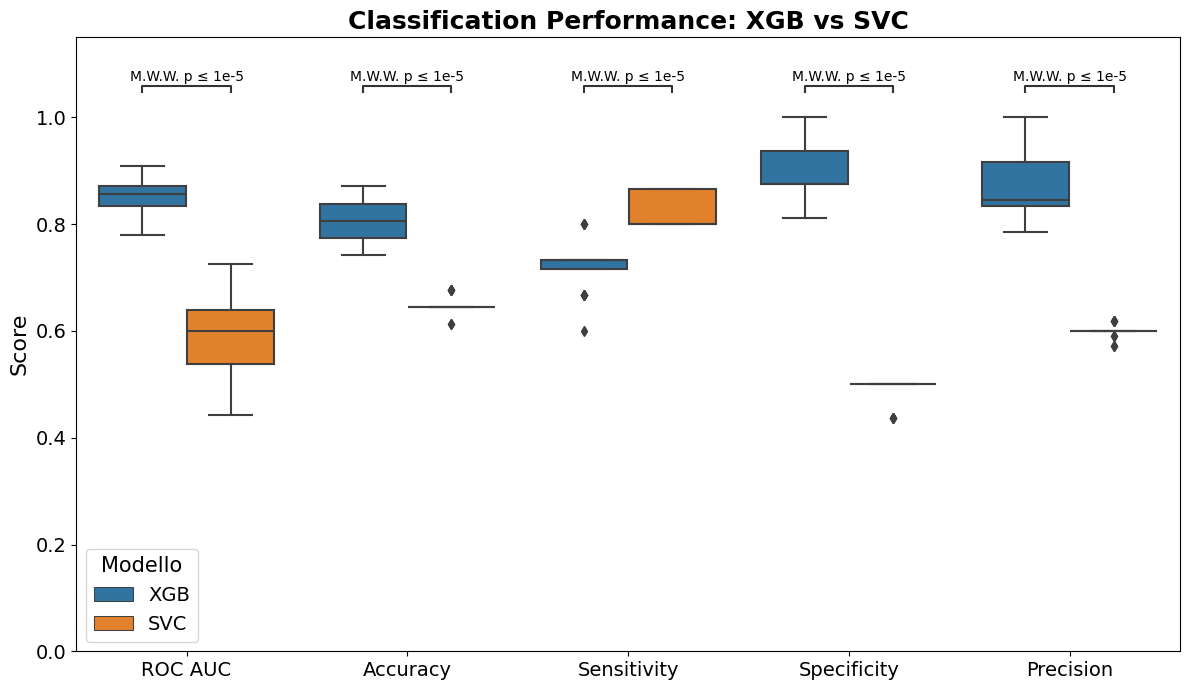

<Figure size 1920x1440 with 0 Axes>

In [58]:
''' XGB vs SVC'''
# Unione
df = pd.concat([df_XGB, df_SVC], ignore_index=True)
df.rename(columns={"roc_auc": "ROC AUC", "accuracy": "Accuracy", "sensitivity": "Sensitivity", "specificity":"Specificity", "precision":"Precision"}, inplace=True)

# Formato long per seaborn
df_long = df.melt(
    id_vars="Modello",
    value_vars=[
        "ROC AUC",
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision"
    ],
    var_name="Metric",
    value_name="Score"
)

#df_long["Modello"] = df_long["Modello"].map({
#    "A": "Polyphenol-Free",
#    "B": "Polyphenol-Rich"
#})


fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df_long,
    x="Metric",
    y="Score",
    hue="Modello",
    ax=ax
)



pairs = [
    (("ROC AUC", "XGB"), ("ROC AUC", "SVC")),
    (("Accuracy", "XGB"), ("Accuracy", "SVC")),
    (("Sensitivity", "XGB"), ("Sensitivity", "SVC")),
    (("Specificity", "XGB"), ("Specificity", "SVC")),
    (("Precision", "XGB"), ("Precision", "SVC")),
]

annotator = Annotator(
    ax,
    pairs,
    data=df_long,
    x="Metric",
    y="Score",
    hue="Modello"
)

annotator.configure(
    test="Mann-Whitney",
    #comparisons_correction="bonferroni",
    #text_format="star",
    text_format="simple",
    loc="outside",
    verbose=0
)

annotator.apply_and_annotate()

ax.set_title(
    "Classification Performance: XGB vs SVC",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Score", fontsize=16)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylim(0, 1.15)

ax.legend(
    title="Modello",
    title_fontsize=15,
    fontsize=14
)

plt.tight_layout()
plt.figure(dpi=300)
plt.show()

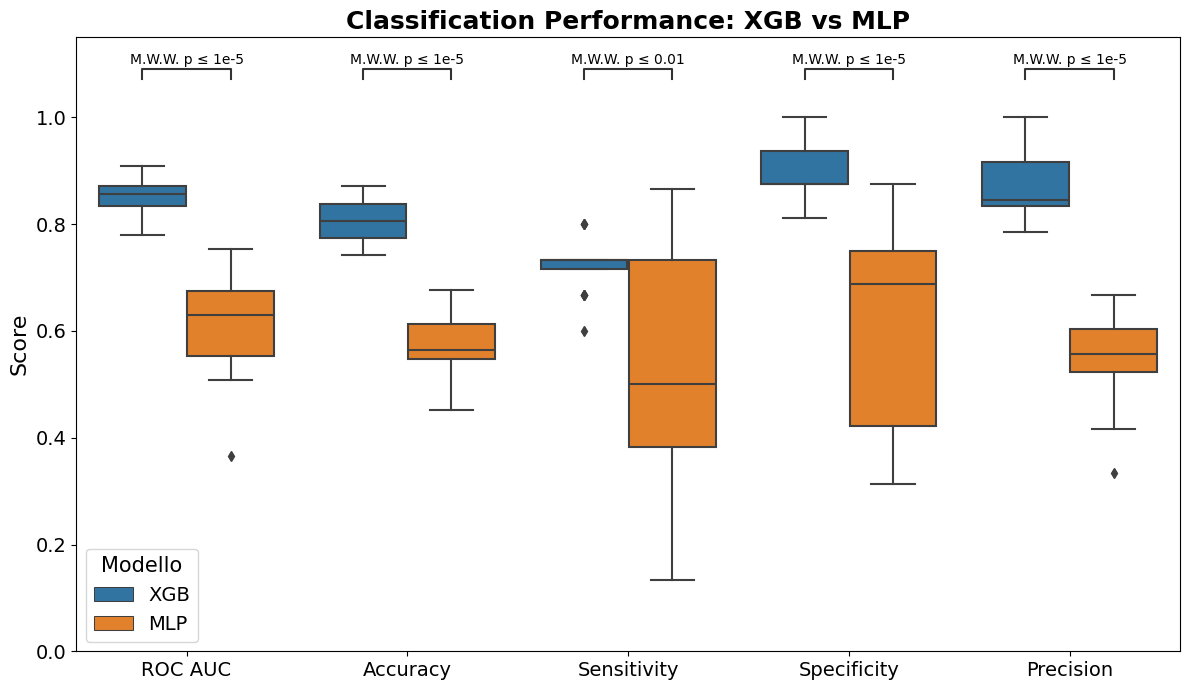

<Figure size 1920x1440 with 0 Axes>

In [57]:
''' XGB vs MLP'''
# Unione
df = pd.concat([df_XGB, df_MLP], ignore_index=True)
df.rename(columns={"roc_auc": "ROC AUC", "accuracy": "Accuracy", "sensitivity": "Sensitivity", "specificity":"Specificity", "precision":"Precision"}, inplace=True)

# Formato long per seaborn
df_long = df.melt(
    id_vars="Modello",
    value_vars=[
        "ROC AUC",
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision"
    ],
    var_name="Metric",
    value_name="Score"
)

#df_long["Modello"] = df_long["Modello"].map({
#    "A": "Polyphenol-Free",
#    "B": "Polyphenol-Rich"
#})


fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df_long,
    x="Metric",
    y="Score",
    hue="Modello",
    ax=ax
)



pairs = [
    (("ROC AUC", "XGB"), ("ROC AUC", "MLP")),
    (("Accuracy", "XGB"), ("Accuracy", "MLP")),
    (("Sensitivity", "XGB"), ("Sensitivity", "MLP")),
    (("Specificity", "XGB"), ("Specificity", "MLP")),
    (("Precision", "XGB"), ("Precision", "MLP")),
]

annotator = Annotator(
    ax,
    pairs,
    data=df_long,
    x="Metric",
    y="Score",
    hue="Modello"
)

annotator.configure(
    test="Mann-Whitney",
    #comparisons_correction="bonferroni",
    #text_format="star",
    text_format="simple",
    loc="outside",
    verbose=0
)

annotator.apply_and_annotate()

ax.set_title(
    "Classification Performance: XGB vs MLP",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Score", fontsize=16)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylim(0, 1.15)

ax.legend(
    title="Modello",
    title_fontsize=15,
    fontsize=14
)

plt.tight_layout()
plt.figure(dpi=300)
plt.show()

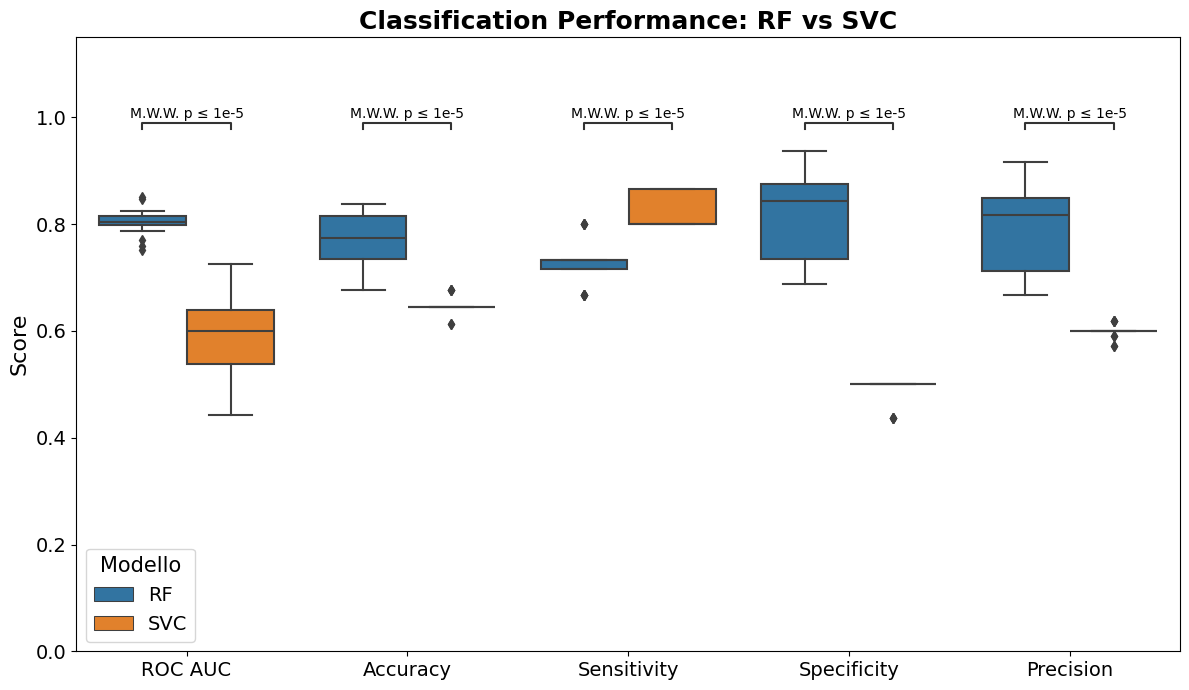

<Figure size 1920x1440 with 0 Axes>

In [56]:
''' RF vs SVC'''
# Unione
df = pd.concat([df_RF, df_SVC], ignore_index=True)
df.rename(columns={"roc_auc": "ROC AUC", "accuracy": "Accuracy", "sensitivity": "Sensitivity", "specificity":"Specificity", "precision":"Precision"}, inplace=True)

# Formato long per seaborn
df_long = df.melt(
    id_vars="Modello",
    value_vars=[
        "ROC AUC",
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision"
    ],
    var_name="Metric",
    value_name="Score"
)

#df_long["Modello"] = df_long["Modello"].map({
#    "A": "Polyphenol-Free",
#    "B": "Polyphenol-Rich"
#})


fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df_long,
    x="Metric",
    y="Score",
    hue="Modello",
    ax=ax
)



pairs = [
    (("ROC AUC", "RF"), ("ROC AUC", "SVC")),
    (("Accuracy", "RF"), ("Accuracy", "SVC")),
    (("Sensitivity", "RF"), ("Sensitivity", "SVC")),
    (("Specificity", "RF"), ("Specificity", "SVC")),
    (("Precision", "RF"), ("Precision", "SVC")),
]

annotator = Annotator(
    ax,
    pairs,
    data=df_long,
    x="Metric",
    y="Score",
    hue="Modello"
)

annotator.configure(
    test="Mann-Whitney",
    #comparisons_correction="bonferroni",
    #text_format="star",
    text_format="simple",
    loc="outside",
    verbose=0
)

annotator.apply_and_annotate()

ax.set_title(
    "Classification Performance: RF vs SVC",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Score", fontsize=16)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylim(0, 1.15)

ax.legend(
    title="Modello",
    title_fontsize=15,
    fontsize=14
)

plt.tight_layout()
plt.figure(dpi=300)
plt.show()

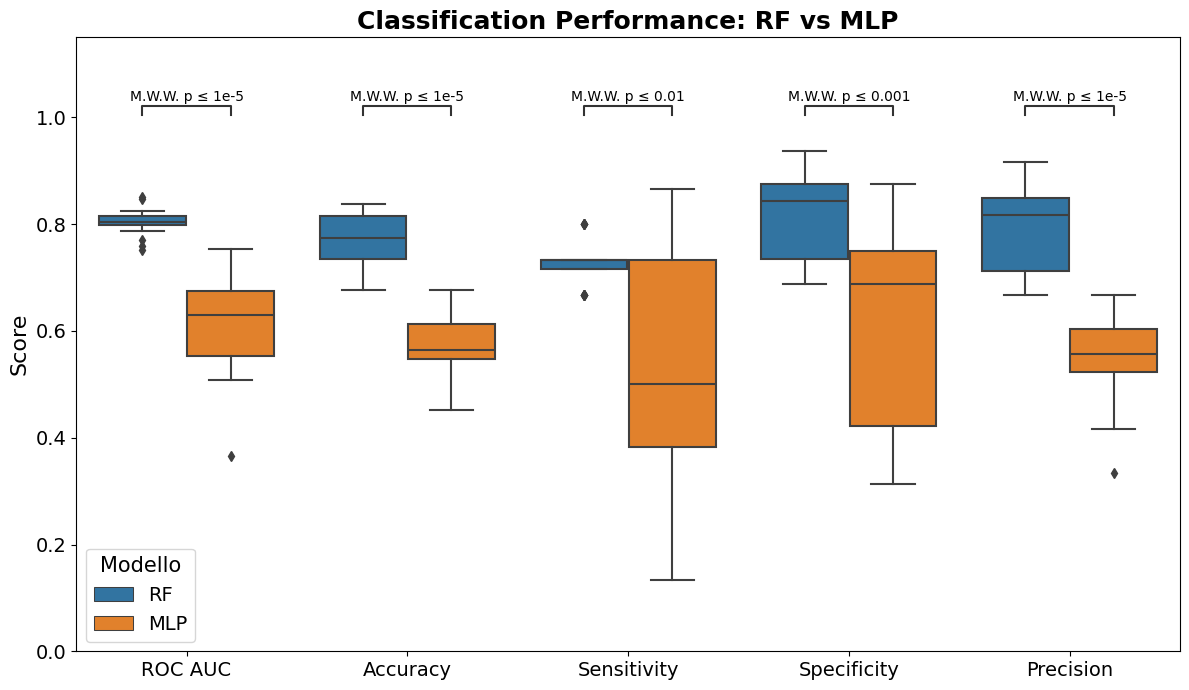

<Figure size 1920x1440 with 0 Axes>

In [55]:
''' RF vs MLP'''
# Unione
df = pd.concat([df_RF, df_MLP], ignore_index=True)
df.rename(columns={"roc_auc": "ROC AUC", "accuracy": "Accuracy", "sensitivity": "Sensitivity", "specificity":"Specificity", "precision":"Precision"}, inplace=True)

# Formato long per seaborn
df_long = df.melt(
    id_vars="Modello",
    value_vars=[
        "ROC AUC",
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision"
    ],
    var_name="Metric",
    value_name="Score"
)

#df_long["Modello"] = df_long["Modello"].map({
#    "A": "Polyphenol-Free",
#    "B": "Polyphenol-Rich"
#})


fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df_long,
    x="Metric",
    y="Score",
    hue="Modello",
    ax=ax
)



pairs = [
    (("ROC AUC", "RF"), ("ROC AUC", "MLP")),
    (("Accuracy", "RF"), ("Accuracy", "MLP")),
    (("Sensitivity", "RF"), ("Sensitivity", "MLP")),
    (("Specificity", "RF"), ("Specificity", "MLP")),
    (("Precision", "RF"), ("Precision", "MLP")),
]

annotator = Annotator(
    ax,
    pairs,
    data=df_long,
    x="Metric",
    y="Score",
    hue="Modello"
)

annotator.configure(
    test="Mann-Whitney",
    #comparisons_correction="bonferroni",
    #text_format="star",
    text_format="simple",
    loc="outside",
    verbose=0
)

annotator.apply_and_annotate()

ax.set_title(
    "Classification Performance: RF vs MLP",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Score", fontsize=16)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylim(0, 1.15)

ax.legend(
    title="Modello",
    title_fontsize=15,
    fontsize=14
)

plt.tight_layout()
plt.figure(dpi=300)
plt.show()

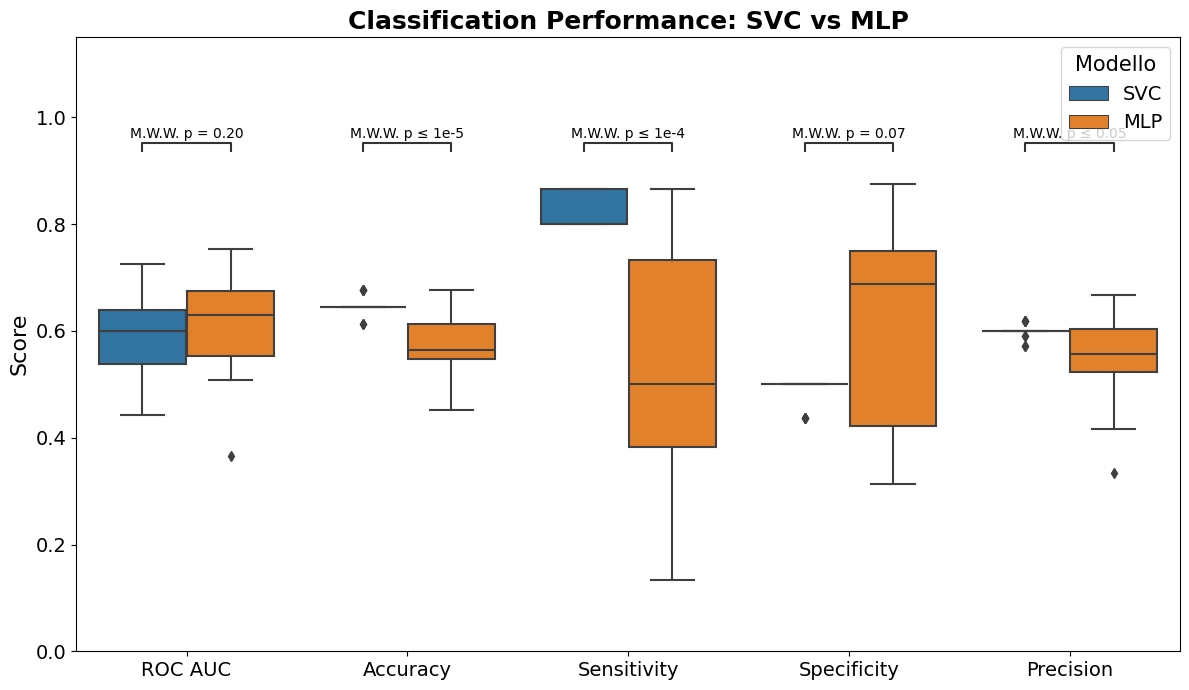

<Figure size 1920x1440 with 0 Axes>

In [54]:
''' SVC vs MLP'''
# Unione
df = pd.concat([df_SVC, df_MLP], ignore_index=True)
df.rename(columns={"roc_auc": "ROC AUC", "accuracy": "Accuracy", "sensitivity": "Sensitivity", "specificity":"Specificity", "precision":"Precision"}, inplace=True)

# Formato long per seaborn
df_long = df.melt(
    id_vars="Modello",
    value_vars=[
        "ROC AUC",
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision"
    ],
    var_name="Metric",
    value_name="Score"
)

#df_long["Modello"] = df_long["Modello"].map({
#    "A": "Polyphenol-Free",
#    "B": "Polyphenol-Rich"
#})


fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df_long,
    x="Metric",
    y="Score",
    hue="Modello",
    ax=ax
)



pairs = [
    (("ROC AUC", "SVC"), ("ROC AUC", "MLP")),
    (("Accuracy", "SVC"), ("Accuracy", "MLP")),
    (("Sensitivity", "SVC"), ("Sensitivity", "MLP")),
    (("Specificity", "SVC"), ("Specificity", "MLP")),
    (("Precision", "SVC"), ("Precision", "MLP")),
]

annotator = Annotator(
    ax,
    pairs,
    data=df_long,
    x="Metric",
    y="Score",
    hue="Modello"
)

annotator.configure(
    test="Mann-Whitney",
    #comparisons_correction="bonferroni",
    #text_format="star",
    text_format="simple",
    loc="outside",
    verbose=0
)

annotator.apply_and_annotate()

ax.set_title(
    "Classification Performance: SVC vs MLP",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Score", fontsize=16)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylim(0, 1.15)

ax.legend(
    title="Modello",
    title_fontsize=15,
    fontsize=14
)

plt.tight_layout()
plt.figure(dpi=300)
plt.show()

## Step 3: Feature selection LD1  XGB

[21:00:57] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 0, fold 0: shape mismatch: value array of shape (4,13) could not be broadcast to indexing result of shape (4,639)
[21:00:57] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 0, fold 1: shape mismatch: value array of shape (3,15) could not be broadcast to indexing result of shape (3,639)
[21:00:57] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP i

[21:00:59] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 2, fold 5: shape mismatch: value array of shape (3,19) could not be broadcast to indexing result of shape (3,639)
[21:00:59] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 2, fold 6: shape mismatch: value array of shape (3,15) could not be broadcast to indexing result of shape (3,639)
[21:00:59] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP i

[21:01:01] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 4, fold 9: shape mismatch: value array of shape (3,20) could not be broadcast to indexing result of shape (3,639)
[21:01:01] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 5, fold 0: shape mismatch: value array of shape (4,16) could not be broadcast to indexing result of shape (4,639)
[21:01:01] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP i

SHAP interno non calcolato nel repeat 7, fold 3: shape mismatch: value array of shape (3,19) could not be broadcast to indexing result of shape (3,639)
[21:01:03] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 7, fold 4: shape mismatch: value array of shape (3,19) could not be broadcast to indexing result of shape (3,639)
[21:01:03] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 7, fold 5: shape mismatch: value array of shape (3,18) could not be broadcast to indexing result of shape (3,639)
[21:01:03] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Savi

SHAP interno non calcolato nel repeat 9, fold 8: shape mismatch: value array of shape (3,17) could not be broadcast to indexing result of shape (3,639)
[21:01:04] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 9, fold 9: shape mismatch: value array of shape (3,18) could not be broadcast to indexing result of shape (3,639)
[21:01:04] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 10, fold 0: shape mismatch: value array of shape (4,16) could not be broadcast to indexing result of shape (4,639)
[21:01:04] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Sav

[21:01:06] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 12, fold 1: shape mismatch: value array of shape (3,18) could not be broadcast to indexing result of shape (3,639)
[21:01:06] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 12, fold 2: shape mismatch: value array of shape (3,16) could not be broadcast to indexing result of shape (3,639)
[21:01:06] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP

[21:01:08] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 14, fold 6: shape mismatch: value array of shape (3,19) could not be broadcast to indexing result of shape (3,639)
[21:01:08] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 14, fold 7: shape mismatch: value array of shape (3,20) could not be broadcast to indexing result of shape (3,639)
[21:01:08] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP

SHAP interno non calcolato nel repeat 16, fold 8: shape mismatch: value array of shape (3,17) could not be broadcast to indexing result of shape (3,639)
[21:01:09] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 16, fold 9: shape mismatch: value array of shape (3,12) could not be broadcast to indexing result of shape (3,639)
[21:01:09] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 17, fold 0: shape mismatch: value array of shape (4,14) could not be broadcast to indexing result of shape (4,639)
[21:01:09] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: S

[21:01:11] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 19, fold 2: shape mismatch: value array of shape (3,19) could not be broadcast to indexing result of shape (3,639)
[21:01:11] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 19, fold 3: shape mismatch: value array of shape (3,18) could not be broadcast to indexing result of shape (3,639)
[21:01:11] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP


Internal repeated cross-validation
Classifier: xgb
CV type: stratified
Sampling: none
Repeats: 20
Folds: 10

           Metric   Mean ± SD       95% CI
          ROC AUC 0.84 (0.02) [0.79, 0.88]
         Accuracy 0.76 (0.04) [0.68, 0.85]
      Sensitivity 0.75 (0.04) [0.67, 0.84]
      Specificity 0.77 (0.08) [0.61, 0.94]
        Precision 0.76 (0.07) [0.63, 0.89]
Average Precision 0.88 (0.02) [0.84, 0.91]


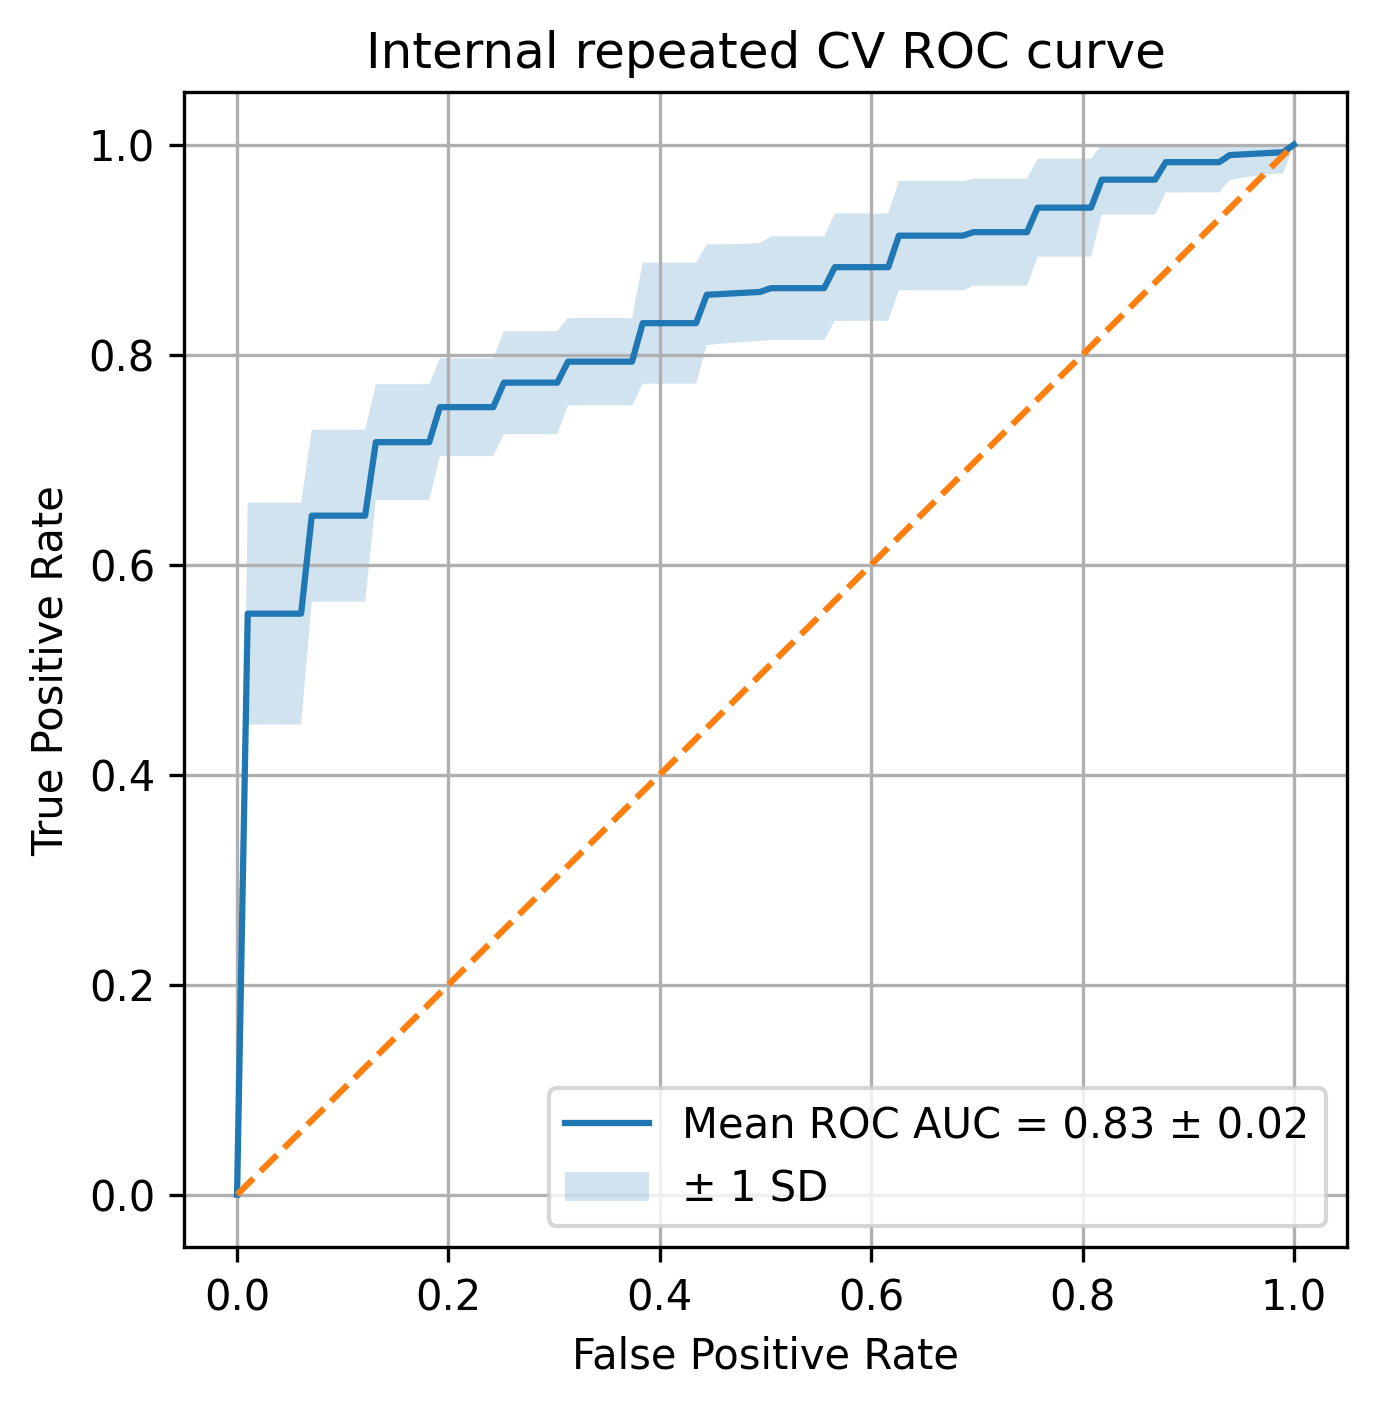

In [13]:
results_L1_XGB = cml.repeated_cv_classification_default(
    df=connectome_feat_1,
    target_col="Label",
    classifier="xgb",
    n_splits=10,
    n_repeats=20,
    feature_selection="l1",
    l1_C=1.0,
    plot_shap=True,
    plot_roc=True,
    print_table=True
)

[21:01:55] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 0, fold 0: shape mismatch: value array of shape (4,14) could not be broadcast to indexing result of shape (4,425)
[21:01:55] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 0, fold 1: shape mismatch: value array of shape (3,15) could not be broadcast to indexing result of shape (3,425)
[21:01:55] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP i

[21:01:56] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 2, fold 4: shape mismatch: value array of shape (3,14) could not be broadcast to indexing result of shape (3,425)
[21:01:56] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 2, fold 5: shape mismatch: value array of shape (3,17) could not be broadcast to indexing result of shape (3,425)
[21:01:56] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP i

[21:01:58] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 4, fold 8: shape mismatch: value array of shape (3,14) could not be broadcast to indexing result of shape (3,425)
[21:01:58] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 4, fold 9: shape mismatch: value array of shape (3,17) could not be broadcast to indexing result of shape (3,425)
[21:01:58] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP i

[21:01:59] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 7, fold 1: shape mismatch: value array of shape (3,15) could not be broadcast to indexing result of shape (3,425)
[21:01:59] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 7, fold 2: shape mismatch: value array of shape (3,20) could not be broadcast to indexing result of shape (3,425)
[21:01:59] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP i

[21:02:00] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 9, fold 5: shape mismatch: value array of shape (3,18) could not be broadcast to indexing result of shape (3,425)
[21:02:00] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 9, fold 6: shape mismatch: value array of shape (3,14) could not be broadcast to indexing result of shape (3,425)
[21:02:00] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP i

[21:02:02] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 11, fold 9: shape mismatch: value array of shape (3,16) could not be broadcast to indexing result of shape (3,425)
[21:02:02] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 12, fold 0: shape mismatch: value array of shape (4,15) could not be broadcast to indexing result of shape (4,425)
[21:02:02] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP

[21:02:03] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 14, fold 2: shape mismatch: value array of shape (3,18) could not be broadcast to indexing result of shape (3,425)
[21:02:03] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 14, fold 3: shape mismatch: value array of shape (3,19) could not be broadcast to indexing result of shape (3,425)
[21:02:03] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP

[21:02:04] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 16, fold 6: shape mismatch: value array of shape (3,16) could not be broadcast to indexing result of shape (3,425)
[21:02:04] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 16, fold 7: shape mismatch: value array of shape (3,14) could not be broadcast to indexing result of shape (3,425)
[21:02:04] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP

[21:02:06] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 18, fold 9: shape mismatch: value array of shape (3,16) could not be broadcast to indexing result of shape (3,425)
[21:02:06] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP interno non calcolato nel repeat 19, fold 0: shape mismatch: value array of shape (4,14) could not be broadcast to indexing result of shape (4,425)
[21:02:06] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
SHAP


Internal repeated cross-validation
Classifier: xgb
CV type: stratified
Sampling: none
Repeats: 20
Folds: 10

           Metric   Mean ± SD       95% CI
          ROC AUC 0.82 (0.03) [0.76, 0.89]
         Accuracy 0.73 (0.05) [0.63, 0.83]
      Sensitivity 0.74 (0.04) [0.66, 0.83]
      Specificity 0.72 (0.09) [0.54, 0.90]
        Precision 0.72 (0.07) [0.58, 0.86]
Average Precision 0.85 (0.04) [0.78, 0.93]


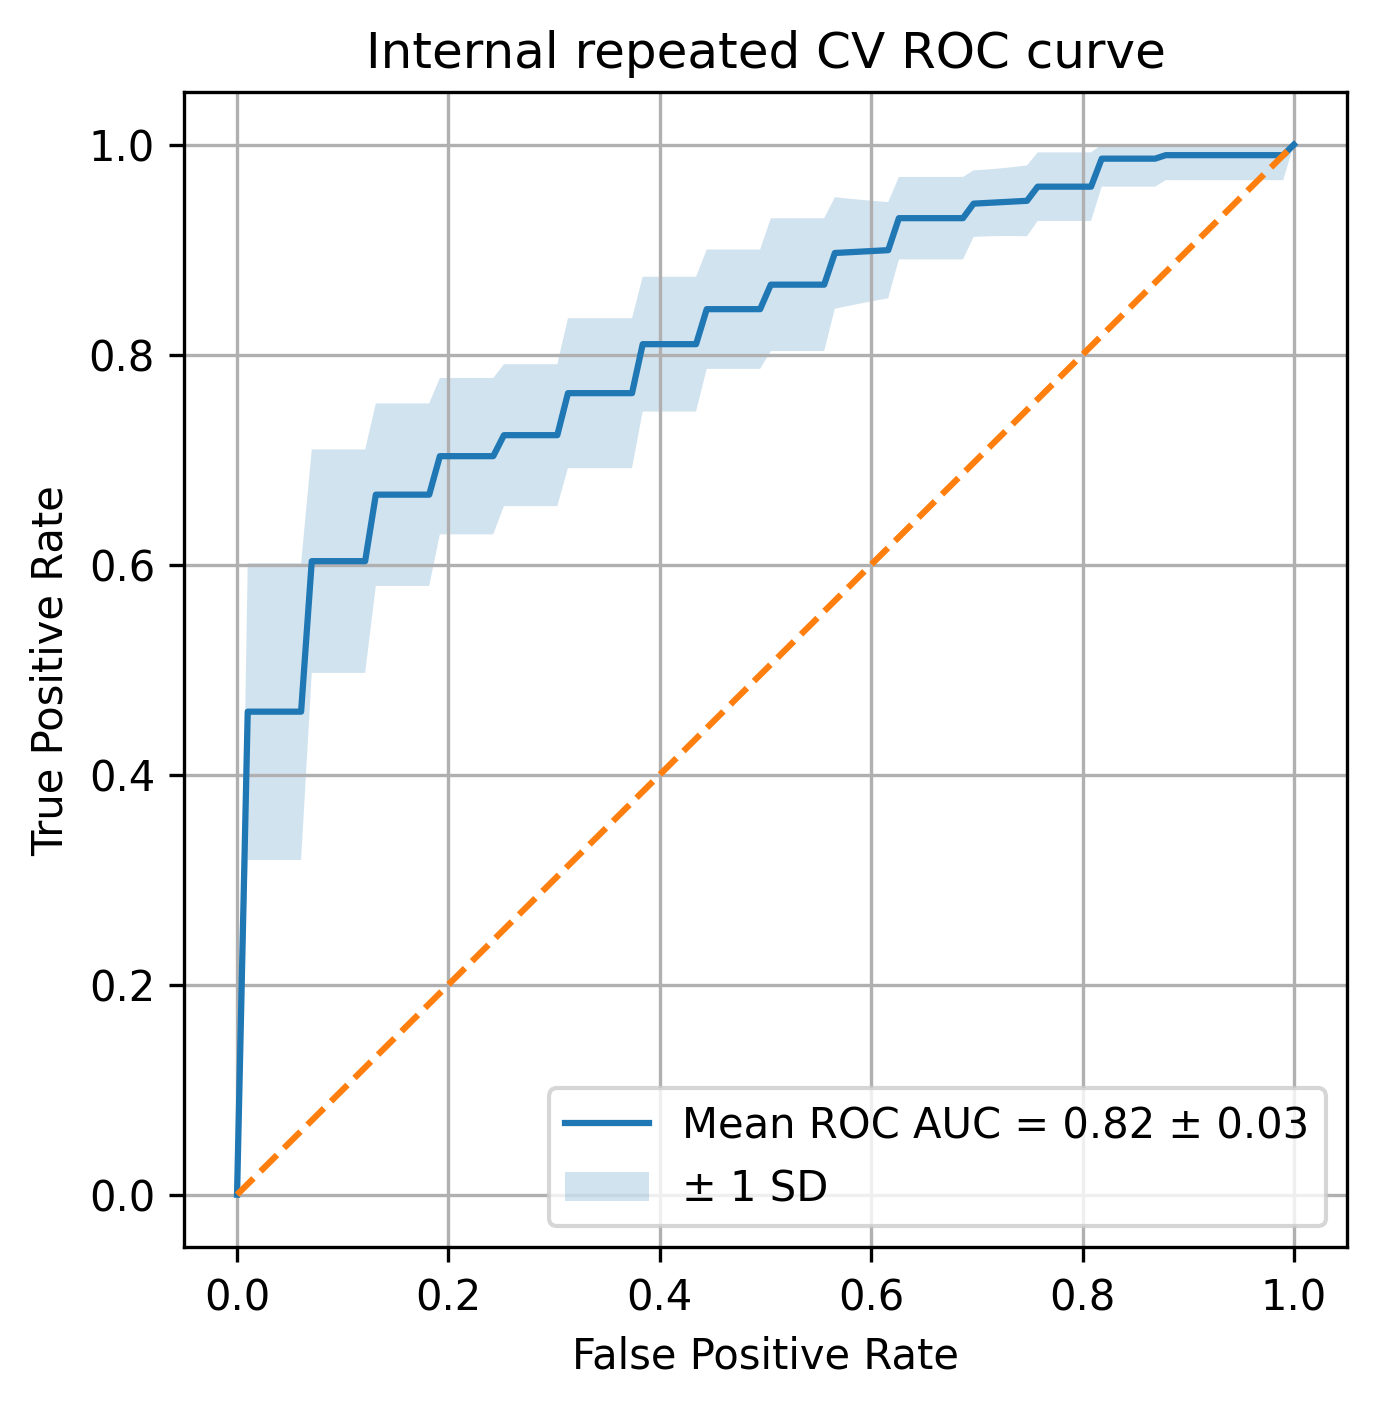

In [14]:
results_L1_XGB = cml.repeated_cv_classification_default(
    df=connectome_feat_2,
    target_col="Label",
    classifier="xgb",
    n_splits=10,
    n_repeats=20,
    feature_selection="l1",
    l1_C=1.0,
    plot_shap=True,
    plot_roc=True,
    print_table=True
)

[12:47:24] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:25] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:25] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:25] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:25] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[12:47:31] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:31] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:31] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:31] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:32] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[12:47:37] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:38] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:38] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:38] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:38] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[12:47:44] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:44] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:44] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:44] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:45] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[12:47:50] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:50] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:51] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:51] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:51] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 

[12:47:57] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:57] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:57] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:57] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[12:47:57] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: 


Internal repeated cross-validation
Classifier: xgb
CV type: stratified
Sampling: none
Repeats: 20
Folds: 10

           Metric   Mean ± SD       95% CI
          ROC AUC 0.85 (0.03) [0.79, 0.92]
         Accuracy 0.81 (0.04) [0.73, 0.89]
      Sensitivity 0.72 (0.05) [0.63, 0.82]
      Specificity 0.89 (0.05) [0.79, 1.00]
        Precision 0.87 (0.06) [0.74, 0.99]
Average Precision 0.89 (0.03) [0.84, 0.95]


[12:47:59] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


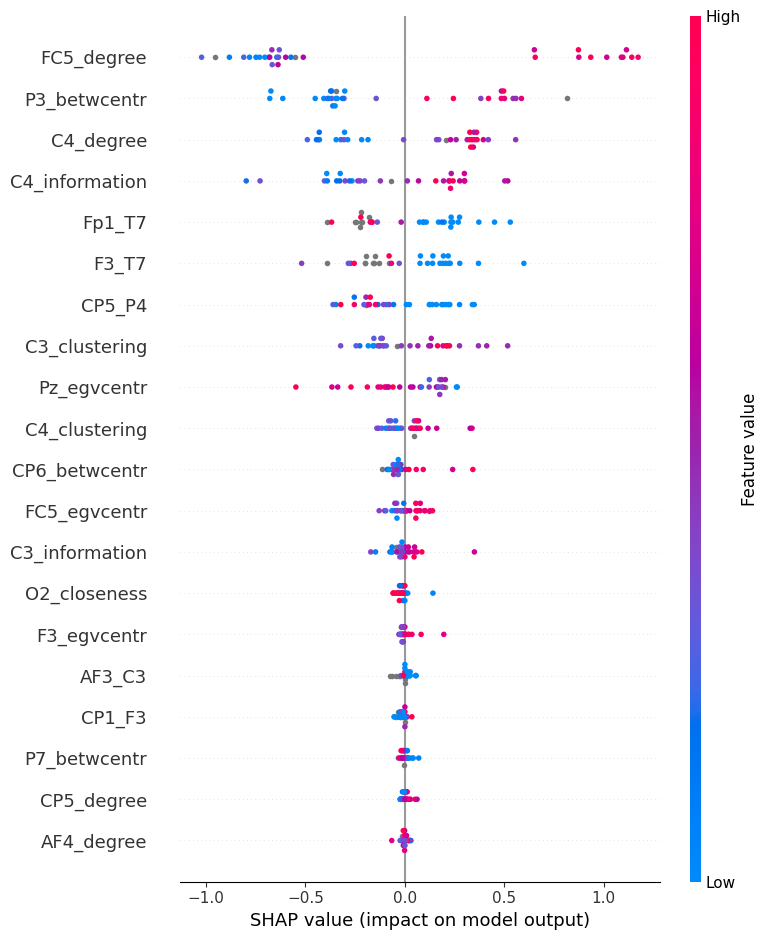

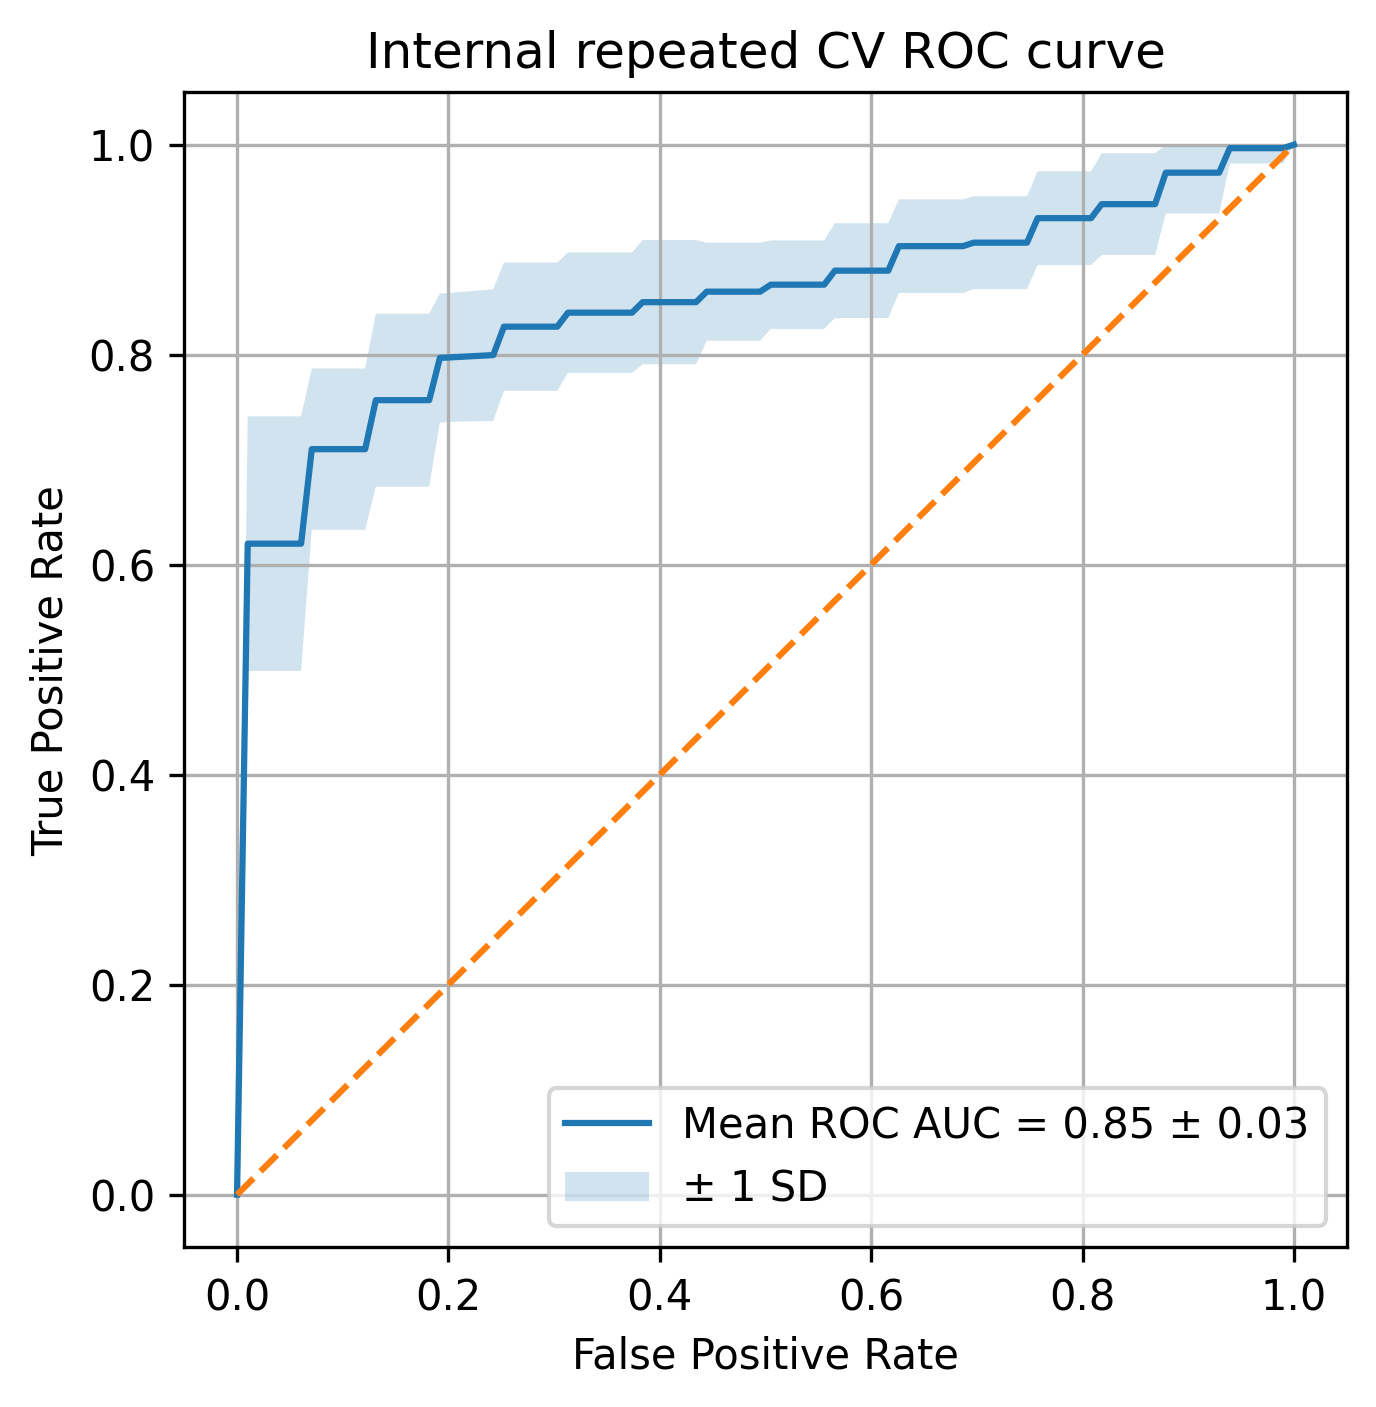

In [26]:
results_L1_XGB = cml.repeated_cv_classification_default(
    df=connectome_feat_1,
    target_col="Label",
    classifier="xgb",
    n_splits=10,
    n_repeats=20,
    plot_shap=True,
    plot_roc=True,
    print_table=True
)

 ## Step 3: Feature selection LD1 RF

SHAP interno non calcolato nel repeat 0, fold 0: shape mismatch: value array of shape (4,14) could not be broadcast to indexing result of shape (4,425)
SHAP interno non calcolato nel repeat 0, fold 1: shape mismatch: value array of shape (3,15) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 0, fold 2: shape mismatch: value array of shape (3,14) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 0, fold 3: shape mismatch: value array of shape (3,17) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 0, fold 4: shape mismatch: value array of shape (3,16) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 0, fold 5: shape mismatch: value array of shape (3,17) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 0, fold 6: shape mismatch: value array of shape (3

SHAP interno non calcolato nel repeat 5, fold 4: shape mismatch: value array of shape (3,20) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 5, fold 5: shape mismatch: value array of shape (3,19) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 5, fold 6: shape mismatch: value array of shape (3,13) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 5, fold 7: shape mismatch: value array of shape (3,11) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 5, fold 8: shape mismatch: value array of shape (3,13) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 5, fold 9: shape mismatch: value array of shape (3,16) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 6, fold 0: shape mismatch: value array of shape (4

SHAP interno non calcolato nel repeat 11, fold 0: shape mismatch: value array of shape (4,12) could not be broadcast to indexing result of shape (4,425)
SHAP interno non calcolato nel repeat 11, fold 1: shape mismatch: value array of shape (3,14) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 11, fold 2: shape mismatch: value array of shape (3,18) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 11, fold 3: shape mismatch: value array of shape (3,17) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 11, fold 4: shape mismatch: value array of shape (3,15) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 11, fold 5: shape mismatch: value array of shape (3,18) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 11, fold 6: shape mismatch: value array of s

SHAP interno non calcolato nel repeat 16, fold 7: shape mismatch: value array of shape (3,14) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 16, fold 8: shape mismatch: value array of shape (3,16) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 16, fold 9: shape mismatch: value array of shape (3,12) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 17, fold 0: shape mismatch: value array of shape (4,14) could not be broadcast to indexing result of shape (4,425)
SHAP interno non calcolato nel repeat 17, fold 1: shape mismatch: value array of shape (3,15) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 17, fold 2: shape mismatch: value array of shape (3,15) could not be broadcast to indexing result of shape (3,425)
SHAP interno non calcolato nel repeat 17, fold 3: shape mismatch: value array of s


Internal repeated cross-validation
Classifier: randomforest
CV type: stratified
Sampling: none
Repeats: 20
Folds: 10

           Metric   Mean ± SD       95% CI
          ROC AUC 0.84 (0.03) [0.78, 0.89]
         Accuracy 0.80 (0.03) [0.73, 0.86]
      Sensitivity 0.77 (0.06) [0.66, 0.89]
      Specificity 0.82 (0.05) [0.72, 0.91]
        Precision 0.80 (0.04) [0.72, 0.88]
Average Precision 0.87 (0.03) [0.82, 0.92]


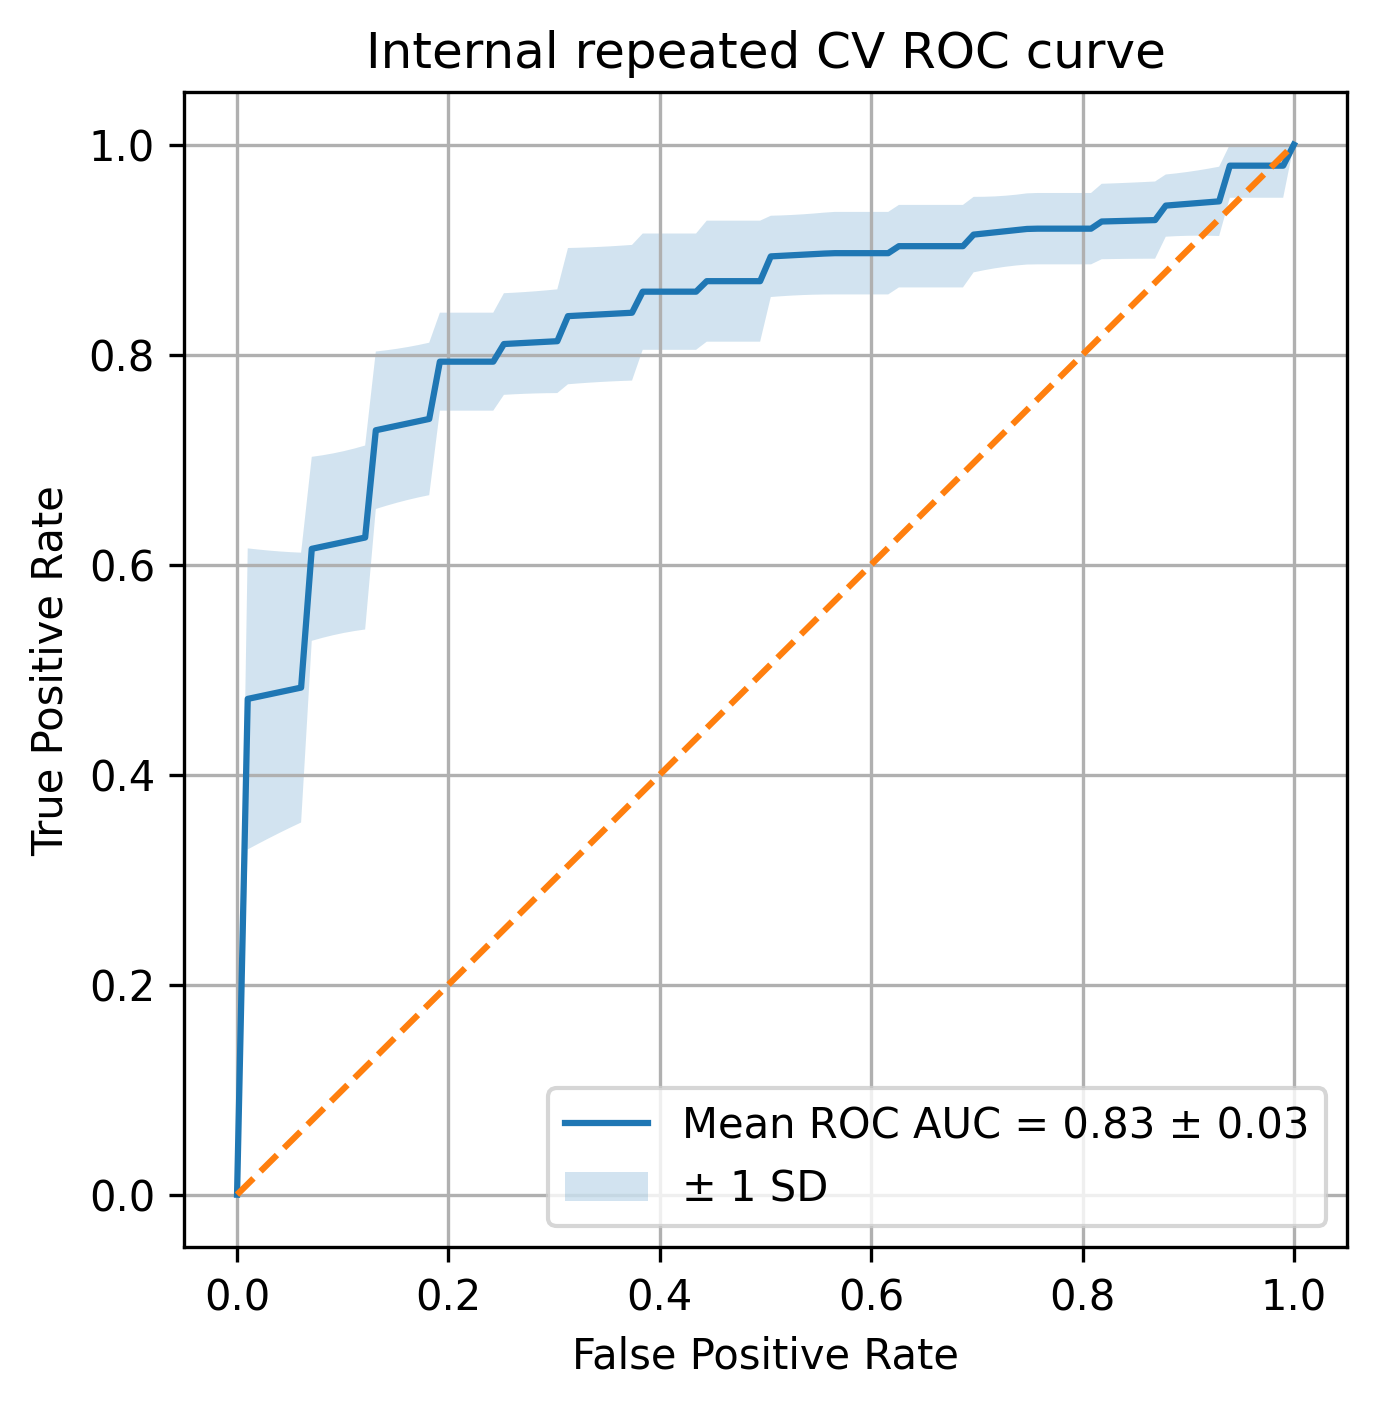

In [21]:
results_L1_RF = cml.repeated_cv_classification_default(
    df=connectome_feat_2,
    target_col="Label",
    classifier="randomforest",
    n_splits=10,
    n_repeats=20,
    feature_selection="l1",
    l1_C=1.0,
    plot_shap=True,
    plot_roc=True,
    print_table=True
)